# Integración del riesgo predictivo con la tesorería

## Objetivo del notebook

El objetivo de este notebook es conectar las dos partes principales del proyecto:

1. el modelo predictivo de riesgo de retraso en el cobro;
2. la simulación diaria de tesorería.

Los notebooks anteriores han permitido construir de forma independiente:

- un modelo capaz de asignar una probabilidad de retraso a cada factura;
- una simulación de tesorería basada en cobros reales y salidas sintéticas;
- distintos escenarios de sensibilidad al calendario de cobros.

El siguiente paso consiste en estudiar si la información predictiva del modelo puede utilizarse para identificar anticipadamente los cobros cuyo retraso tendría mayor relevancia para la gestión de tesorería.

## Principio metodológico

La integración debe mantener el mismo principio temporal utilizado durante todo el proyecto:

> ninguna factura puede ser evaluada utilizando un modelo que haya sido entrenado con esa misma factura o con información futura respecto a ella.

Por este motivo no se utilizará el modelo final entrenado sobre `train + validation` para puntuar retrospectivamente todo el histórico.

Se generarán únicamente **scores temporalmente out-of-sample**.

### Período validation

El modelo se entrenará exclusivamente con `train` y generará probabilidades para `validation`.

### Período test

El modelo se entrenará con `train + validation` y generará probabilidades para `test`.

De esta forma, todas las probabilidades utilizadas posteriormente en los escenarios de tesorería serán predicciones realizadas sobre observaciones no utilizadas durante el entrenamiento correspondiente.

## Comparaciones posteriores

Una vez construidos los scores se compararán distintos criterios de priorización:

- selección aleatoria;
- mayor importe;
- mayor riesgo predictivo;
- riesgo predictivo ponderado por exposición monetaria.

Todos los criterios se evaluarán sobre el mismo universo de facturas y utilizando reglas de estrés comparables.

Esto permitirá estudiar si el modelo predictivo aporta información adicional para la gestión de liquidez.

In [2]:
from pathlib import Path
import json

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

In [3]:
PROJECT_ROOT = Path("..")

GOLD_DIR = (
    PROJECT_ROOT
    / "data"
    / "gold"
)

PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

METADATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "metadata"
)

RISK_GOLD_FILE = (
    GOLD_DIR
    / "gold_invoice_risk.parquet"
)

CASH_MOVEMENTS_FILE = (
    PROCESSED_DIR
    / "cash_movements.parquet"
)

DAILY_CASHFLOW_FILE = (
    GOLD_DIR
    / "gold_daily_cashflow.parquet"
)

SIMULATION_CONFIG_FILE = (
    METADATA_DIR
    / "cashflow_simulation_config.json"
)

print(
    "Risk Gold:",
    RISK_GOLD_FILE.resolve()
)

print(
    "Cash movements:",
    CASH_MOVEMENTS_FILE.resolve()
)

print(
    "Daily cashflow:",
    DAILY_CASHFLOW_FILE.resolve()
)

Risk Gold: C:\Users\jesus\OneDrive\Documents\Evolve Data Science\portfolio\sistema_predictivo_tesoreria_y_riesgo_de_impago\data\gold\gold_invoice_risk.parquet
Cash movements: C:\Users\jesus\OneDrive\Documents\Evolve Data Science\portfolio\sistema_predictivo_tesoreria_y_riesgo_de_impago\data\processed\cash_movements.parquet
Daily cashflow: C:\Users\jesus\OneDrive\Documents\Evolve Data Science\portfolio\sistema_predictivo_tesoreria_y_riesgo_de_impago\data\gold\gold_daily_cashflow.parquet


## 1. Carga y validación de las fuentes

Este notebook utiliza únicamente datasets previamente generados y validados.

### Modelo predictivo

`gold_invoice_risk.parquet`

Contiene:

- identificadores;
- fechas;
- features disponibles en el momento de emisión;
- target `late_payment`.

### Tesorería

`cash_movements.parquet`

Contiene el libro único de movimientos de caja.

`gold_daily_cashflow.parquet`

Contiene la serie diaria del escenario base.

Los datasets se cargarán sin modificar sus valores originales.

### Cargar datasets

In [4]:
risk_df = pd.read_parquet(
    RISK_GOLD_FILE
)

cash_movements = pd.read_parquet(
    CASH_MOVEMENTS_FILE
)

daily_cashflow = pd.read_parquet(
    DAILY_CASHFLOW_FILE
)

with open(
    SIMULATION_CONFIG_FILE,
    "r",
    encoding="utf-8"
) as file:

    simulation_metadata = json.load(
        file
    )

### Dimensiones

In [5]:
dataset_shapes = pd.Series({
    "risk_rows": (
        risk_df.shape[0]
    ),

    "risk_columns": (
        risk_df.shape[1]
    ),

    "cash_movement_rows": (
        cash_movements.shape[0]
    ),

    "cash_movement_columns": (
        cash_movements.shape[1]
    ),

    "daily_cashflow_rows": (
        daily_cashflow.shape[0]
    ),

    "daily_cashflow_columns": (
        daily_cashflow.shape[1]
    ),
})

dataset_shapes

risk_rows                 2466
risk_columns                48
cash_movement_rows        2777
cash_movement_columns       12
daily_cashflow_rows        669
daily_cashflow_columns       8
dtype: int64

### Normalizar tipos

In [6]:
risk_df[
    "invoice_date"
] = pd.to_datetime(
    risk_df[
        "invoice_date"
    ]
).dt.normalize()

risk_df[
    "due_date"
] = pd.to_datetime(
    risk_df[
        "due_date"
    ]
).dt.normalize()

risk_df[
    "invoice_id"
] = (
    risk_df[
        "invoice_id"
    ]
    .astype(str)
)

risk_df[
    "customer_id"
] = (
    risk_df[
        "customer_id"
    ]
    .astype(str)
)

cash_movements[
    "date"
] = pd.to_datetime(
    cash_movements[
        "date"
    ]
).dt.normalize()

cash_movements[
    "reference_id"
] = (
    cash_movements[
        "reference_id"
    ]
    .astype(str)
)

### Validaciones generales

In [7]:
source_checks = pd.Series({
    "risk_duplicate_invoice_id": (
        risk_df[
            "invoice_id"
        ]
        .duplicated()
        .sum()
    ),

    "risk_missing_invoice_date": (
        risk_df[
            "invoice_date"
        ]
        .isna()
        .sum()
    ),

    "risk_missing_target": (
        risk_df[
            "late_payment"
        ]
        .isna()
        .sum()
    ),

    "cash_duplicate_movement_id": (
        cash_movements[
            "movement_id"
        ]
        .duplicated()
        .sum()
    ),

    "cash_missing_date": (
        cash_movements[
            "date"
        ]
        .isna()
        .sum()
    ),

    "cash_missing_amount": (
        cash_movements[
            "amount"
        ]
        .isna()
        .sum()
    ),
})

display(source_checks)

assert risk_df[
    "invoice_id"
].is_unique

assert risk_df[
    "invoice_date"
].notna().all()

assert risk_df[
    "late_payment"
].notna().all()

assert cash_movements[
    "movement_id"
].is_unique

assert cash_movements[
    "date"
].notna().all()

assert cash_movements[
    "amount"
].notna().all()

print(
    "✓ Fuentes cargadas y validadas."
)

risk_duplicate_invoice_id     0
risk_missing_invoice_date     0
risk_missing_target           0
cash_duplicate_movement_id    0
cash_missing_date             0
cash_missing_amount           0
dtype: int64

✓ Fuentes cargadas y validadas.


## 2. Reconstrucción exacta del Modelo C

La integración utilizará el modelo seleccionado durante la fase de comparación:

`Logistic Regression — Modelo C`

El modelo utiliza 34 features.

La selección incluye:

- características de la factura;
- variables temporales;
- historial comercial;
- historial conocido de pagos;
- ratios relativos al comportamiento previo;
- indicadores de disponibilidad de histórico.

No se utilizan:

- identificadores de cliente como predictor;
- información posterior a la emisión;
- variables explícitas de exposición añadidas en el Modelo D;
- `Disputed`;
- `PaperlessDate`;
- información derivada de `SettledDate`.

### Features Modelo C

In [8]:
invoice_features = [
    "invoice_amount",
    "log_invoice_amount",
    "paperless_bill",
    "country_code",
]

temporal_features = [
    "invoice_year",
    "invoice_month",
    "invoice_quarter",
    "invoice_weekday",
    "is_month_start",
    "is_month_end",
    "days_since_dataset_start",
]

history_features = [
    "previous_issued_count",
    "previous_avg_invoice_amount",
    "previous_median_invoice_amount",
    "days_since_previous_invoice",

    "previous_settled_count",
    "previous_late_count",
    "previous_late_rate",
    "previous_avg_delay",
    "previous_median_delay",
    "previous_max_delay",
    "last_payment_delay",
    "days_since_last_payment",

    "last_3_late_rate",
    "last_3_avg_delay",
    "last_5_late_rate",
    "last_5_avg_delay",

    "amount_vs_previous_avg",
    "amount_vs_previous_median",
    "amount_diff_vs_previous_avg",

    "is_new_customer",
    "has_payment_history",
    "has_3_payment_history",
    "has_5_payment_history",
]

MODEL_C_FEATURES = (
    invoice_features
    + temporal_features
    + history_features
)

print(
    "Número de features:",
    len(
        MODEL_C_FEATURES
    )
)

Número de features: 34


### Validar Features

In [9]:
missing_features = [
    feature
    for feature in MODEL_C_FEATURES
    if feature not in risk_df.columns
]

assert not missing_features, (
    "Faltan features del Modelo C: "
    f"{missing_features}"
)

assert (
    len(
        MODEL_C_FEATURES
    )
    == 34
)

print(
    "✓ Modelo C contiene las 34 features esperadas."
)

✓ Modelo C contiene las 34 features esperadas.


### Features categoricas

In [10]:
CATEGORICAL_FEATURES = [
    "paperless_bill",
    "country_code",
    "invoice_month",
    "invoice_quarter",
    "invoice_weekday",
]

NUMERIC_FEATURES = [
    feature
    for feature in MODEL_C_FEATURES
    if feature not in CATEGORICAL_FEATURES
]

print(
    "Numéricas:",
    len(
        NUMERIC_FEATURES
    )
)

print(
    "Categóricas:",
    len(
        CATEGORICAL_FEATURES
    )
)

Numéricas: 29
Categóricas: 5


### Funcion reconstruccion de pipeline

In [11]:
def build_model_c_pipeline():
    numeric_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),
            (
                "scaler",
                StandardScaler()
            ),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                )
            ),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore"
                )
            ),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                numeric_pipeline,
                NUMERIC_FEATURES
            ),
            (
                "categorical",
                categorical_pipeline,
                CATEGORICAL_FEATURES
            ),
        ]
    )

    model = LogisticRegression(
        max_iter=2000,
        random_state=42,
    )

    return Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "classifier",
                model
            ),
        ]
    )

## 3. Reconstrucción del split temporal

Se utilizarán exactamente los períodos congelados durante la fase de modelado.

### Train

Facturas anteriores al:

`05/05/2013`

### Validation

Desde:

`05/05/2013`

hasta:

`19/08/2013`

### Test

A partir del:

`20/08/2013`

La distribución original era:

- train: 1.719 facturas;
- validation: 381 facturas;
- test: 366 facturas.

El objetivo de reconstruir explícitamente estas ventanas es garantizar que los scores utilizados en tesorería mantienen la misma separación temporal que la evaluación original.

### Cortes temporales

In [12]:
TRAIN_END_EXCLUSIVE = pd.Timestamp(
    "2013-05-05"
)

VALIDATION_END_EXCLUSIVE = pd.Timestamp(
    "2013-08-20"
)

### Splits

In [13]:
risk_train = (
    risk_df[
        risk_df[
            "invoice_date"
        ]
        < TRAIN_END_EXCLUSIVE
    ]
    .copy()
)

risk_validation = (
    risk_df[
        risk_df[
            "invoice_date"
        ]
        .between(
            TRAIN_END_EXCLUSIVE,
            VALIDATION_END_EXCLUSIVE,
            inclusive="left",
        )
    ]
    .copy()
)

risk_test = (
    risk_df[
        risk_df[
            "invoice_date"
        ]
        >= VALIDATION_END_EXCLUSIVE
    ]
    .copy()
)

### Validar splits

In [14]:
split_summary = pd.DataFrame({
    "split": [
        "train",
        "validation",
        "test",
    ],

    "rows": [
        len(
            risk_train
        ),
        len(
            risk_validation
        ),
        len(
            risk_test
        ),
    ],

    "positive_count": [
        risk_train[
            "late_payment"
        ].sum(),

        risk_validation[
            "late_payment"
        ].sum(),

        risk_test[
            "late_payment"
        ].sum(),
    ],

    "positive_rate": [
        risk_train[
            "late_payment"
        ].mean(),

        risk_validation[
            "late_payment"
        ].mean(),

        risk_test[
            "late_payment"
        ].mean(),
    ],

    "start_date": [
        risk_train[
            "invoice_date"
        ].min(),

        risk_validation[
            "invoice_date"
        ].min(),

        risk_test[
            "invoice_date"
        ].min(),
    ],

    "end_date": [
        risk_train[
            "invoice_date"
        ].max(),

        risk_validation[
            "invoice_date"
        ].max(),

        risk_test[
            "invoice_date"
        ].max(),
    ],
})

display(split_summary)

assert len(
    risk_train
) == 1719

assert len(
    risk_validation
) == 381

assert len(
    risk_test
) == 366

assert risk_train[
    "late_payment"
].sum() == 656

assert risk_validation[
    "late_payment"
].sum() == 124

assert risk_test[
    "late_payment"
].sum() == 97

assert (
    risk_train[
        "invoice_date"
    ].max()
    <
    risk_validation[
        "invoice_date"
    ].min()
)

assert (
    risk_validation[
        "invoice_date"
    ].max()
    <
    risk_test[
        "invoice_date"
    ].min()
)

print(
    "✓ Split temporal original reproducido exactamente."
)

,split,rows,positive_count,positive_rate,start_date,end_date
0,train,1719,656,0.381617,2012-01-03,2013-05-04
1,validation,381,124,0.325459,2013-05-05,2013-08-19
2,test,366,97,0.265027,2013-08-20,2013-12-02


✓ Split temporal original reproducido exactamente.


## 4. Generación de scores temporalmente out-of-sample

Se generarán dos conjuntos de probabilidades.

### Scores de validation

El modelo se entrenará exclusivamente con las 1.719 observaciones de train.

Después generará probabilidades para las 381 facturas de validation.

### Scores de test

El modelo se volverá a entrenar utilizando conjuntamente:

`train + validation`

y generará probabilidades para las 366 facturas de test.

En ambos casos, la factura evaluada queda completamente fuera del entrenamiento del modelo que produce su score.

Estos scores constituyen la base válida para la posterior integración con tesorería.

### Modelo Train → Validation

In [15]:
validation_model = (
    build_model_c_pipeline()
)

validation_model.fit(
    risk_train[
        MODEL_C_FEATURES
    ],
    risk_train[
        "late_payment"
    ],
)

validation_probability = (
    validation_model
    .predict_proba(
        risk_validation[
            MODEL_C_FEATURES
        ]
    )[:, 1]
)

### Modelo Train + Validation → Test

In [16]:
risk_train_validation = (
    pd.concat(
        [
            risk_train,
            risk_validation,
        ],
        ignore_index=True,
    )
    .sort_values(
        [
            "invoice_date",
            "invoice_id",
        ]
    )
    .reset_index(
        drop=True
    )
)

test_model = (
    build_model_c_pipeline()
)

test_model.fit(
    risk_train_validation[
        MODEL_C_FEATURES
    ],
    risk_train_validation[
        "late_payment"
    ],
)

test_probability = (
    test_model
    .predict_proba(
        risk_test[
            MODEL_C_FEATURES
        ]
    )[:, 1]
)

### Comprobar reproduccion del rendimiento

In [17]:
oos_performance = pd.DataFrame([
    {
        "period": "VALIDATION_OOS",

        "rows": (
            len(
                risk_validation
            )
        ),

        "prevalence": (
            risk_validation[
                "late_payment"
            ].mean()
        ),

        "roc_auc": (
            roc_auc_score(
                risk_validation[
                    "late_payment"
                ],
                validation_probability
            )
        ),

        "pr_auc": (
            average_precision_score(
                risk_validation[
                    "late_payment"
                ],
                validation_probability
            )
        ),
    },

    {
        "period": "TEST_OOS",

        "rows": (
            len(
                risk_test
            )
        ),

        "prevalence": (
            risk_test[
                "late_payment"
            ].mean()
        ),

        "roc_auc": (
            roc_auc_score(
                risk_test[
                    "late_payment"
                ],
                test_probability
            )
        ),

        "pr_auc": (
            average_precision_score(
                risk_test[
                    "late_payment"
                ],
                test_probability
            )
        ),
    },
])

oos_performance

,period,rows,prevalence,roc_auc,pr_auc
0,VALIDATION_OOS,381,0.325459,0.904387,0.801798
1,TEST_OOS,366,0.265027,0.859043,0.693359


### Tabla scores validation

In [18]:
validation_scores = (
    risk_validation[
        [
            "invoice_id",
            "customer_id",
            "invoice_date",
            "due_date",
            "invoice_amount",
            "late_payment",
        ]
    ]
    .copy()
)

validation_scores[
    "predicted_risk"
] = (
    validation_probability
)

validation_scores[
    "scoring_period"
] = "VALIDATION_OOS"

### Scores test

In [19]:
test_scores = (
    risk_test[
        [
            "invoice_id",
            "customer_id",
            "invoice_date",
            "due_date",
            "invoice_amount",
            "late_payment",
        ]
    ]
    .copy()
)

test_scores[
    "predicted_risk"
] = (
    test_probability
)

test_scores[
    "scoring_period"
] = "TEST_OOS"

### Combinar scores OOS

In [20]:
oos_risk_scores = (
    pd.concat(
        [
            validation_scores,
            test_scores,
        ],
        ignore_index=True,
    )
    .sort_values(
        [
            "invoice_date",
            "invoice_id",
        ]
    )
    .reset_index(
        drop=True
    )
)

oos_risk_scores.head()

,invoice_id,customer_id,invoice_date,due_date,invoice_amount,late_payment,predicted_risk,scoring_period
0,2871447909,6708-DPYTF,2013-05-05,2013-06-04,76.49,0,0.894140,VALIDATION_OOS
1,3776405169,7329-TWKLF,2013-05-05,2013-06-04,66.46,0,0.214564,VALIDATION_OOS
2,4242889718,7758-WKLVM,2013-05-05,2013-06-04,81.23,1,0.896134,VALIDATION_OOS
3,4747988353,2687-XWAMA,2013-05-05,2013-06-04,73.15,0,0.039605,VALIDATION_OOS
4,7282316945,7209-MDWKR,2013-05-05,2013-06-04,74.70,1,0.699990,VALIDATION_OOS


### Validacion anti-leakage

In [21]:
assert (
    len(
        oos_risk_scores
    )
    ==
    len(
        risk_validation
    )
    +
    len(
        risk_test
    )
)

assert oos_risk_scores[
    "invoice_id"
].is_unique

assert oos_risk_scores[
    "predicted_risk"
].between(
    0,
    1
).all()

assert (
    validation_scores[
        "invoice_date"
    ].min()
    >
    risk_train[
        "invoice_date"
    ].max()
)

assert (
    test_scores[
        "invoice_date"
    ].min()
    >
    risk_train_validation[
        "invoice_date"
    ].max()
)

print(
    "✓ Scores temporalmente out-of-sample validados."
)

✓ Scores temporalmente out-of-sample validados.


### Resumen scores

In [22]:
oos_score_summary = (
    oos_risk_scores
    .groupby(
        "scoring_period"
    )
    .agg(
        invoice_count=(
            "invoice_id",
            "count"
        ),

        start_date=(
            "invoice_date",
            "min"
        ),

        end_date=(
            "invoice_date",
            "max"
        ),

        observed_late_rate=(
            "late_payment",
            "mean"
        ),

        mean_predicted_risk=(
            "predicted_risk",
            "mean"
        ),

        median_predicted_risk=(
            "predicted_risk",
            "median"
        ),

        minimum_predicted_risk=(
            "predicted_risk",
            "min"
        ),

        maximum_predicted_risk=(
            "predicted_risk",
            "max"
        ),
    )
)

oos_score_summary

,invoice_count,start_date,end_date,observed_late_rate,mean_predicted_risk,median_predicted_risk,minimum_predicted_risk,maximum_predicted_risk
scoring_period,,,,,,,,
TEST_OOS,366,2013-08-20,2013-12-02,0.265027,0.245056,0.098845,0.001160,0.965489
VALIDATION_OOS,381,2013-05-05,2013-08-19,0.325459,0.406079,0.323518,0.001893,0.991541


## 5. Unión entre scores de riesgo y movimientos de tesorería

Los scores predictivos están asociados a facturas, mientras que la simulación de tesorería está construida a partir de movimientos de caja.

La relación se realizará mediante:

`invoice_id`

En `cash_movements.parquet`, el identificador de la factura original está almacenado como:

`reference_id`

para los movimientos:

`CUSTOMER_RECEIPT`

## Universo integrado

No todas las facturas con score out-of-sample estarán necesariamente dentro del horizonte de tesorería.

La simulación termina el 30 de noviembre de 2013.

Por tanto, algunas facturas del período test pueden liquidarse fuera del horizonte o haber sido emitidas demasiado cerca del final.

El análisis integrado utilizará únicamente la intersección entre:

- facturas con score temporalmente out-of-sample;
- cobros reales presentes en la simulación de tesorería.

Las restantes observaciones no se eliminarán del modelo original.

Simplemente quedan fuera del experimento conjunto riesgo–tesorería.

### Construir universo de cobros reales

In [23]:
receipt_universe = (
    cash_movements[
        cash_movements[
            "direction"
        ].eq(
            "CASH_IN"
        )
        &
        cash_movements[
            "movement_type"
        ].eq(
            "CUSTOMER_RECEIPT"
        )
        &
        cash_movements[
            "data_origin"
        ].eq(
            "REAL"
        )
    ]
    [
        [
            "movement_id",
            "date",
            "amount",
            "reference_id",
            "counterparty_id",
        ]
    ]
    .copy()
)

receipt_universe = (
    receipt_universe
    .rename(
        columns={
            "date": "receipt_date",
            "reference_id": "invoice_id",
            "counterparty_id": "customer_id_receipt",
        }
    )
)

receipt_universe[
    "invoice_id"
] = (
    receipt_universe[
        "invoice_id"
    ]
    .astype(str)
)

receipt_universe.head()

,movement_id,receipt_date,amount,invoice_id,customer_id_receipt
0,COL_000817,2012-02-01,28.84,3314980148,6077-FDQRK
1,COL_001945,2012-02-01,74.01,7867318195,5148-SYKLB
3,COL_001430,2012-02-02,32.78,5831823402,2687-XWAMA
4,COL_000545,2012-02-03,47.07,2195380883,6627-ELFBK
5,COL_001299,2012-02-03,47.75,5215762025,7372-CESLR


### Validar cobros

In [24]:
receipt_checks = pd.Series({
    "receipt_count": (
        len(
            receipt_universe
        )
    ),

    "unique_invoice_count": (
        receipt_universe[
            "invoice_id"
        ].nunique()
    ),

    "receipt_amount": (
        receipt_universe[
            "amount"
        ].sum()
    ),

    "first_receipt_date": (
        receipt_universe[
            "receipt_date"
        ].min()
    ),

    "last_receipt_date": (
        receipt_universe[
            "receipt_date"
        ].max()
    ),
})

display(receipt_checks)

assert receipt_universe[
    "movement_id"
].is_unique

assert receipt_universe[
    "invoice_id"
].is_unique

assert (
    receipt_universe[
        "amount"
    ] > 0
).all()

assert receipt_universe[
    "receipt_date"
].between(
    pd.Timestamp(
        simulation_metadata[
            "simulation_start_date"
        ]
    ),
    pd.Timestamp(
        simulation_metadata[
            "simulation_end_date"
        ]
    ),
).all()

print(
    "✓ Universo de cobros reales validado."
)

receipt_count                          2366
unique_invoice_count                   2366
receipt_amount                    141713.03
first_receipt_date      2012-02-01 00:00:00
last_receipt_date       2013-11-30 00:00:00
dtype: object

✓ Universo de cobros reales validado.


### Unir scores con tesoreria

In [25]:
risk_treasury_universe = (
    receipt_universe
    .merge(
        oos_risk_scores,
        on="invoice_id",
        how="inner",
        validate="one_to_one",
    )
)

display(risk_treasury_universe.head())

assert risk_treasury_universe[
    "movement_id"
].is_unique

assert risk_treasury_universe[
    "invoice_id"
].is_unique

assert np.allclose(
    risk_treasury_universe[
        "amount"
    ],
    risk_treasury_universe[
        "invoice_amount"
    ]
)

assert (
    risk_treasury_universe[
        "customer_id_receipt"
    ].astype(str)
    ==
    risk_treasury_universe[
        "customer_id"
    ].astype(str)
).all()

print(
    "✓ Riesgo predictivo y tesorería "
    "unidos correctamente."
)

,movement_id,receipt_date,amount,invoice_id,customer_id_receipt,customer_id,invoice_date,due_date,invoice_amount,late_payment,predicted_risk,scoring_period
0,COL_000771,2013-05-09,41.72,3155625555,2687-XWAMA,2687-XWAMA,2013-05-06,2013-06-05,41.72,0,0.028146,VALIDATION_OOS
1,COL_001172,2013-05-12,73.15,4747988353,2687-XWAMA,2687-XWAMA,2013-05-05,2013-06-04,73.15,0,0.039605,VALIDATION_OOS
2,COL_001485,2013-05-15,79.87,6018471272,0187-ERLSR,0187-ERLSR,2013-05-07,2013-06-06,79.87,0,0.059640,VALIDATION_OOS
3,COL_000420,2013-05-21,66.16,1671932723,9286-VLKMI,9286-VLKMI,2013-05-20,2013-06-19,66.16,0,0.006610,VALIDATION_OOS
4,COL_001048,2013-05-21,59.78,4232761255,9758-AIEIK,9758-AIEIK,2013-05-07,2013-06-06,59.78,0,0.116919,VALIDATION_OOS


✓ Riesgo predictivo y tesorería unidos correctamente.


### Target coincide con la fecha real de cobro

In [26]:
late_payment_from_cashflow = (
    risk_treasury_universe[
        "receipt_date"
    ]
    >
    risk_treasury_universe[
        "due_date"
    ]
).astype(int)

assert (
    late_payment_from_cashflow
    ==
    risk_treasury_universe[
        "late_payment"
    ]
).all()

print(
    "✓ Target late_payment coherente "
    "con due_date y receipt_date."
)

✓ Target late_payment coherente con due_date y receipt_date.


### Cobertura de la integracion

In [27]:
integration_coverage = pd.Series({
    "cashflow_receipt_count": (
        len(
            receipt_universe
        )
    ),

    "oos_score_count": (
        len(
            oos_risk_scores
        )
    ),

    "integrated_receipt_count": (
        len(
            risk_treasury_universe
        )
    ),

    "cashflow_receipts_with_oos_score_pct": (
        len(
            risk_treasury_universe
        )
        /
        len(
            receipt_universe
        )
    ),

    "cashflow_receipt_amount": (
        receipt_universe[
            "amount"
        ].sum()
    ),

    "integrated_receipt_amount": (
        risk_treasury_universe[
            "amount"
        ].sum()
    ),

    "cashflow_amount_with_oos_score_pct": (
        risk_treasury_universe[
            "amount"
        ].sum()
        /
        receipt_universe[
            "amount"
        ].sum()
    ),

    "oos_score_cashflow_coverage_pct": (
    len(
        risk_treasury_universe
    )
    /
    len(
        oos_risk_scores
    )
),

    "first_scored_invoice_date": (
        risk_treasury_universe[
            "invoice_date"
        ].min()
    ),

    "last_scored_invoice_date": (
        risk_treasury_universe[
            "invoice_date"
        ].max()
    ),

    "first_scored_receipt_date": (
        risk_treasury_universe[
            "receipt_date"
        ].min()
    ),

    "last_scored_receipt_date": (
        risk_treasury_universe[
            "receipt_date"
        ].max()
    ),
})

integration_coverage

cashflow_receipt_count                                 2366
oos_score_count                                         747
integrated_receipt_count                                659
cashflow_receipts_with_oos_score_pct               0.278529
cashflow_receipt_amount                           141713.03
integrated_receipt_amount                          39921.32
cashflow_amount_with_oos_score_pct                 0.281705
oos_score_cashflow_coverage_pct                    0.882195
first_scored_invoice_date               2013-05-05 00:00:00
last_scored_invoice_date                2013-11-21 00:00:00
first_scored_receipt_date               2013-05-09 00:00:00
last_scored_receipt_date                2013-11-30 00:00:00
dtype: object

### Cobertura por periodo

In [28]:
integration_coverage_by_period = (
    risk_treasury_universe
    .groupby(
        "scoring_period"
    )
    .agg(
        receipt_count=(
            "invoice_id",
            "count"
        ),

        receipt_amount=(
            "amount",
            "sum"
        ),

        observed_late_rate=(
            "late_payment",
            "mean"
        ),

        mean_predicted_risk=(
            "predicted_risk",
            "mean"
        ),

        first_invoice_date=(
            "invoice_date",
            "min"
        ),

        last_invoice_date=(
            "invoice_date",
            "max"
        ),

        first_receipt_date=(
            "receipt_date",
            "min"
        ),

        last_receipt_date=(
            "receipt_date",
            "max"
        ),
    )
)

integration_coverage_by_period

,receipt_count,receipt_amount,observed_late_rate,mean_predicted_risk,first_invoice_date,last_invoice_date,first_receipt_date,last_receipt_date
scoring_period,,,,,,,,
TEST_OOS,278,16997.10,0.205036,0.224113,2013-08-20,2013-11-21,2013-08-22,2013-11-30
VALIDATION_OOS,381,22924.22,0.325459,0.406079,2013-05-05,2013-08-19,2013-05-09,2013-09-30


### Cobertura temporal y censura al final del horizonte

La integración entre el modelo predictivo y la tesorería presenta una limitación temporal importante.

El período de test contiene 366 facturas, pero únicamente 278 aparecen como cobros dentro del horizonte de tesorería, que finaliza el 30 de noviembre de 2013.

Por tanto, la cobertura del período test es aproximadamente del 76 %.

Esta pérdida de observaciones no es completamente aleatoria.

Las facturas que se cobran después del final del horizonte tienen mayor probabilidad de corresponder a pagos tardíos o a facturas emitidas cerca del final del período.

Esto se observa al comparar la prevalencia:

- test completo: aproximadamente 26,5 % de retrasos;
- test presente en tesorería: aproximadamente 20,5 %.

Por tanto, utilizar únicamente las facturas test presentes en `cash_movements` produciría una muestra temporalmente truncada y menos representativa del riesgo real del período.

En cambio, las 381 facturas del período validation están completamente representadas dentro del horizonte de tesorería.

Por este motivo, el experimento principal de integración riesgo–tesorería utilizará `VALIDATION_OOS`.

El período test se mantendrá como evidencia independiente de generalización del modelo predictivo, pero no se utilizará como universo principal para comparar estrategias financieras dentro del horizonte actual.

### Diagnostico

In [29]:
oos_coverage_by_period = (
    oos_risk_scores
    .groupby(
        "scoring_period"
    )
    .agg(
        oos_invoice_count=(
            "invoice_id",
            "count"
        ),

        oos_invoice_amount=(
            "invoice_amount",
            "sum"
        ),

        oos_late_rate=(
            "late_payment",
            "mean"
        ),

        oos_mean_predicted_risk=(
            "predicted_risk",
            "mean"
        ),
    )
)

integrated_coverage_by_period = (
    risk_treasury_universe
    .groupby(
        "scoring_period"
    )
    .agg(
        integrated_invoice_count=(
            "invoice_id",
            "count"
        ),

        integrated_invoice_amount=(
            "amount",
            "sum"
        ),

        integrated_late_rate=(
            "late_payment",
            "mean"
        ),

        integrated_mean_predicted_risk=(
            "predicted_risk",
            "mean"
        ),
    )
)

coverage_diagnostic = (
    oos_coverage_by_period
    .join(
        integrated_coverage_by_period,
        how="left",
    )
)

coverage_diagnostic[
    "invoice_coverage_pct"
] = (
    coverage_diagnostic[
        "integrated_invoice_count"
    ]
    /
    coverage_diagnostic[
        "oos_invoice_count"
    ]
)

coverage_diagnostic[
    "amount_coverage_pct"
] = (
    coverage_diagnostic[
        "integrated_invoice_amount"
    ]
    /
    coverage_diagnostic[
        "oos_invoice_amount"
    ]
)

coverage_diagnostic[
    "late_rate_change"
] = (
    coverage_diagnostic[
        "integrated_late_rate"
    ]
    -
    coverage_diagnostic[
        "oos_late_rate"
    ]
)

coverage_diagnostic[
    "mean_risk_change"
] = (
    coverage_diagnostic[
        "integrated_mean_predicted_risk"
    ]
    -
    coverage_diagnostic[
        "oos_mean_predicted_risk"
    ]
)

coverage_diagnostic

,oos_invoice_count,oos_invoice_amount,oos_late_rate,oos_mean_predicted_risk,integrated_invoice_count,integrated_invoice_amount,integrated_late_rate,integrated_mean_predicted_risk,invoice_coverage_pct,amount_coverage_pct,late_rate_change,mean_risk_change
scoring_period,,,,,,,,,,,,
TEST_OOS,366,22222.02,0.265027,0.245056,278,16997.10,0.205036,0.224113,0.759563,0.764876,-0.059991,-0.020943
VALIDATION_OOS,381,22924.22,0.325459,0.406079,381,22924.22,0.325459,0.406079,1.000000,1.000000,0.000000,0.000000


### Universo prinicipal

In [30]:
primary_risk_treasury_universe = (
    risk_treasury_universe[
        risk_treasury_universe[
            "scoring_period"
        ].eq(
            "VALIDATION_OOS"
        )
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

assert (
    set(
        primary_risk_treasury_universe[
            "invoice_id"
        ]
    )
    ==
    set(
        risk_validation[
            "invoice_id"
        ]
        .astype(str)
    )
)

assert (
    len(
        primary_risk_treasury_universe
    )
    ==
    len(
        risk_validation
    )
)

assert (
    primary_risk_treasury_universe[
        "invoice_id"
    ].is_unique
)

assert np.isclose(
    primary_risk_treasury_universe[
        "late_payment"
    ].mean(),
    risk_validation[
        "late_payment"
    ].mean()
)

print(
    "✓ Universo principal riesgo–tesorería "
    "sin truncamiento temporal."
)

✓ Universo principal riesgo–tesorería sin truncamiento temporal.


### Resumen universo principal

In [31]:
primary_universe_summary = pd.Series({
    "invoice_count": (
        len(
            primary_risk_treasury_universe
        )
    ),

    "total_amount": (
        primary_risk_treasury_universe[
            "amount"
        ].sum()
    ),

    "late_invoice_count": (
        primary_risk_treasury_universe[
            "late_payment"
        ].sum()
    ),

    "late_rate": (
        primary_risk_treasury_universe[
            "late_payment"
        ].mean()
    ),

    "mean_predicted_risk": (
        primary_risk_treasury_universe[
            "predicted_risk"
        ].mean()
    ),

    "median_predicted_risk": (
        primary_risk_treasury_universe[
            "predicted_risk"
        ].median()
    ),

    "first_invoice_date": (
        primary_risk_treasury_universe[
            "invoice_date"
        ].min()
    ),

    "last_invoice_date": (
        primary_risk_treasury_universe[
            "invoice_date"
        ].max()
    ),

    "first_receipt_date": (
        primary_risk_treasury_universe[
            "receipt_date"
        ].min()
    ),

    "last_receipt_date": (
        primary_risk_treasury_universe[
            "receipt_date"
        ].max()
    ),
})

primary_universe_summary

invoice_count                            381
total_amount                        22924.22
late_invoice_count                       124
late_rate                           0.325459
mean_predicted_risk                 0.406079
median_predicted_risk               0.323518
first_invoice_date       2013-05-05 00:00:00
last_invoice_date        2013-08-19 00:00:00
first_receipt_date       2013-05-09 00:00:00
last_receipt_date        2013-09-30 00:00:00
dtype: object

## Conclusiones del primer bloque de integración

La primera fase del notebook permite validar correctamente la conexión entre el modelo predictivo y la simulación de tesorería.

### Reconstrucción del modelo

El Modelo C reproduce exactamente el rendimiento obtenido durante la fase original de modelado.

Sobre validation:

- ROC-AUC = 0,904;
- PR-AUC = 0,802.

Sobre test:

- ROC-AUC = 0,859;
- PR-AUC = 0,693.

Esto confirma que se ha reconstruido correctamente la misma regresión logística utilizada durante la selección y evaluación final.

### Scores temporalmente out-of-sample

Las probabilidades utilizadas se generan respetando estrictamente la estructura temporal:

- validation es evaluado mediante un modelo entrenado exclusivamente con train;
- test es evaluado mediante un modelo entrenado con train + validation.

Por tanto, ninguna factura es puntuada por un modelo que haya sido entrenado con ella.

La integración mantiene así el principio de ausencia de data leakage utilizado durante todo el proyecto.

### Unión entre riesgo y tesorería

Los scores predictivos se han relacionado con los cobros mediante `invoice_id`.

El universo integrado contiene conjuntamente:

- fecha de emisión;
- fecha de cobro;
- importe;
- comportamiento real de pago;
- probabilidad estimada de retraso;
- identificador del movimiento de tesorería.

De las 747 facturas con score out-of-sample, 659 disponen de un cobro dentro del horizonte principal de tesorería.

### Limitación temporal del período test

La cobertura no es homogénea entre los dos períodos.

Las 381 facturas de validation están completamente representadas dentro de la simulación.

En cambio, únicamente 278 de las 366 facturas de test presentan un cobro dentro del horizonte que finaliza el 30 de noviembre de 2013.

Esta pérdida de observaciones está relacionada con el límite temporal del cashflow.

Además, el subconjunto test integrado presenta una tasa de retraso inferior a la del test completo.

Por tanto, utilizar únicamente las facturas test que aparecen en tesorería introduciría un sesgo de truncamiento temporal.

### Universo principal de integración

Para mantener una comparación metodológicamente limpia, los escenarios principales de riesgo–tesorería utilizarán exclusivamente las 381 facturas de `VALIDATION_OOS`.

Este período presenta:

- cobertura completa dentro de tesorería;
- scores completamente out-of-sample;
- ausencia de selección condicionada por el final del horizonte.

El período test seguirá utilizándose como evidencia independiente de generalización del modelo predictivo, pero no como universo principal para el experimento financiero.

El siguiente bloque comparará diferentes estrategias de priorización sobre este mismo conjunto de 381 facturas:

- selección aleatoria;
- mayor importe;
- mayor riesgo predictivo;
- riesgo predictivo ponderado por exposición.

### Alcance de la integración predictiva

La integración entre el modelo de riesgo y la tesorería debe interpretarse como un experimento de priorización y estrés financiero.

El modelo predictivo genera el score utilizando únicamente información disponible en el momento de emisión de la factura.

Sin embargo, la simulación de tesorería utilizada como escenario base contiene las fechas de cobro finalmente observadas.

Los siguientes escenarios utilizarán el score para decidir **qué facturas someter a un retraso adicional**, pero partirán de su fecha real de cobro como referencia.

Por tanto, el experimento responde principalmente a la pregunta:

> ¿qué impacto tendría sobre la liquidez un deterioro adicional de los cobros identificados previamente como prioritarios por distintas estrategias?

No debe interpretarse como una previsión completa de la fecha futura de cobro realizada en el momento de emisión.

El objetivo es evaluar el valor del score como herramienta de:

- priorización;
- identificación preventiva;
- análisis de exposición;
- construcción de escenarios de tesorería.

Una previsión completamente ex-ante de tesorería requeriría modelar directamente la distribución de la fecha o número de días hasta el cobro, aspecto que queda fuera del alcance del modelo binario desarrollado en este proyecto.

## 6. Estrategias de priorización de facturas

El universo principal de integración contiene 381 facturas del período `VALIDATION_OOS`.

Todas ellas cumplen simultáneamente:

- score predictivo generado fuera de muestra;
- cobertura completa dentro del horizonte de tesorería;
- disponibilidad del importe de la factura;
- disponibilidad de la fecha real de cobro;
- disponibilidad del comportamiento real `late_payment`.

Sobre este mismo universo se construirán cuatro estrategias de priorización.

### RANDOM 25

Selecciona aleatoriamente el aproximadamente el aproximadamente el 25 % de las facturas.

Funciona como benchmark neutral.

### HIGH VALUE 25

Selecciona el aproximadamente el 25 % de las facturas de mayor importe.

Representa una estrategia basada únicamente en exposición monetaria.

### HIGH RISK 25

Selecciona el aproximadamente el 25 % de las facturas con mayor probabilidad estimada de retraso.

Representa la utilización directa del modelo predictivo.

### RISK × VALUE 25

Selecciona el aproximadamente el 25 % de las facturas con mayor valor de:

`predicted_risk × invoice_amount`

Esta medida intenta combinar:

- probabilidad estimada de retraso;
- exposición monetaria asociada al cobro.

No debe interpretarse como una pérdida esperada en sentido contable.

El modelo predice retraso, no impago definitivo, y sus probabilidades no presentan calibración perfecta.

Por tanto, `risk × value` se utilizará exclusivamente como criterio de ranking financiero.

## Comparabilidad

Todas las estrategias:

- utilizarán exactamente el mismo universo;
- seleccionarán el mismo número de facturas;
- se construirán sin utilizar el target `late_payment`;
- se evaluarán posteriormente utilizando el comportamiento realmente observado.

Esto permitirá separar:

`probabilidad de retraso`

de:

`consecuencia económica potencial`.

### Referencia del universo

In [32]:
primary_universe_reference = pd.Series({
    "invoice_count": (
        len(
            primary_risk_treasury_universe
        )
    ),

    "total_amount": (
        primary_risk_treasury_universe[
            "amount"
        ].sum()
    ),

    "late_invoice_count": (
        primary_risk_treasury_universe[
            "late_payment"
        ].sum()
    ),

    "late_rate": (
        primary_risk_treasury_universe[
            "late_payment"
        ].mean()
    ),

    "late_invoice_amount": (
        primary_risk_treasury_universe.loc[
            primary_risk_treasury_universe[
                "late_payment"
            ].eq(1),
            "amount"
        ].sum()
    ),

    "mean_predicted_risk": (
        primary_risk_treasury_universe[
            "predicted_risk"
        ].mean()
    ),
})

primary_universe_reference

invoice_count            381.000000
total_amount           22924.220000
late_invoice_count       124.000000
late_rate                  0.325459
late_invoice_amount     7842.300000
mean_predicted_risk        0.406079
dtype: float64

### Crear score riesgo x exposicion

In [33]:
primary_risk_treasury_universe[
    "risk_weighted_exposure"
] = (
    primary_risk_treasury_universe[
        "predicted_risk"
    ]
    *
    primary_risk_treasury_universe[
        "amount"
    ]
)

assert primary_risk_treasury_universe[
    "risk_weighted_exposure"
].notna().all()

assert (
    primary_risk_treasury_universe[
        "risk_weighted_exposure"
    ] >= 0
).all()

print(
    "✓ Score riesgo × exposición calculado."
)

✓ Score riesgo × exposición calculado.


### Configuracion comun

In [34]:
PRIORITIZATION_SHARE = 0.25

PRIORITIZATION_COUNT = int(
    np.ceil(
        len(
            primary_risk_treasury_universe
        )
        *
        PRIORITIZATION_SHARE
    )
)

print(
    "Facturas disponibles:",
    len(
        primary_risk_treasury_universe
    )
)

print(
    "Porcentaje seleccionado:",
    f"{PRIORITIZATION_SHARE:.0%}"
)

print(
    "Facturas por estrategia:",
    PRIORITIZATION_COUNT
)

Facturas disponibles: 381
Porcentaje seleccionado: 25%
Facturas por estrategia: 96


### Funcion determinista para ranking

In [35]:
def select_top_invoices(
    data,
    ranking_column,
    selection_count,
):
    selected = (
        data
        .sort_values(
            [
                ranking_column,
                "movement_id",
            ],
            ascending=[
                False,
                True,
            ]
        )
        .head(
            selection_count
        )
        .copy()
    )

    return selected

### Seleccion aleatoria reproducible

In [36]:
prioritization_rng = np.random.default_rng(
    int(
        simulation_metadata[
            "random_seed"
        ]
    )
    + 5000
)

random_selected_ids = (
    prioritization_rng.choice(
        primary_risk_treasury_universe[
            "movement_id"
        ].to_numpy(),
        size=PRIORITIZATION_COUNT,
        replace=False,
    )
)

random_25 = (
    primary_risk_treasury_universe[
        primary_risk_treasury_universe[
            "movement_id"
        ].isin(
            random_selected_ids
        )
    ]
    .copy()
)

### Selecciones por ranking

In [37]:
high_value_25 = (
    select_top_invoices(
        data=primary_risk_treasury_universe,
        ranking_column="amount",
        selection_count=PRIORITIZATION_COUNT,
    )
)

high_risk_25 = (
    select_top_invoices(
        data=primary_risk_treasury_universe,
        ranking_column="predicted_risk",
        selection_count=PRIORITIZATION_COUNT,
    )
)

risk_x_value_25 = (
    select_top_invoices(
        data=primary_risk_treasury_universe,
        ranking_column="risk_weighted_exposure",
        selection_count=PRIORITIZATION_COUNT,
    )
)

### Validar igualdad de tamaños

In [38]:
selection_sizes = pd.Series({
    "RANDOM_25": (
        len(
            random_25
        )
    ),

    "HIGH_VALUE_25": (
        len(
            high_value_25
        )
    ),

    "HIGH_RISK_25": (
        len(
            high_risk_25
        )
    ),

    "RISK_X_VALUE_25": (
        len(
            risk_x_value_25
        )
    ),
})

display(selection_sizes)

assert (
    selection_sizes
    == PRIORITIZATION_COUNT
).all()

for selected_df in [
    random_25,
    high_value_25,
    high_risk_25,
    risk_x_value_25,
]:
    assert selected_df[
        "movement_id"
    ].is_unique

print(
    "✓ Todas las estrategias seleccionan "
    "exactamente el mismo número de facturas."
)

RANDOM_25          96
HIGH_VALUE_25      96
HIGH_RISK_25       96
RISK_X_VALUE_25    96
dtype: int64

✓ Todas las estrategias seleccionan exactamente el mismo número de facturas.


### Evaluación de las estrategias

El target real `late_payment` no se ha utilizado para seleccionar ninguna factura.

A partir de este punto se utilizará únicamente para evaluar a posteriori la calidad de cada priorización.

Se analizarán dos dimensiones.

### Concentración de riesgo

- tasa real de retraso entre las facturas seleccionadas;
- porcentaje de retrasos reales capturados;
- lift respecto a la prevalencia general.

### Concentración de exposición

- importe total seleccionado;
- porcentaje del importe total;
- importe correspondiente a facturas realmente tardías;
- porcentaje del importe tardío total capturado.

Una estrategia puede ser buena concentrando retrasos sin concentrar mucho importe, o viceversa.

Por este motivo no se utilizará una única métrica para valorar todas las estrategias.

### Funcion de resumen

In [39]:
def summarize_prioritization(
    full_data,
    selected_data,
    strategy_name,
):
    total_count = (
        len(
            full_data
        )
    )

    total_amount = (
        full_data[
            "amount"
        ].sum()
    )

    total_late_count = (
        full_data[
            "late_payment"
        ].sum()
    )

    total_late_amount = (
        full_data.loc[
            full_data[
                "late_payment"
            ].eq(1),
            "amount"
        ].sum()
    )

    selected_late_count = (
        selected_data[
            "late_payment"
        ].sum()
    )

    selected_late_amount = (
        selected_data.loc[
            selected_data[
                "late_payment"
            ].eq(1),
            "amount"
        ].sum()
    )

    baseline_late_rate = (
        full_data[
            "late_payment"
        ].mean()
    )

    selected_late_rate = (
        selected_data[
            "late_payment"
        ].mean()
    )

    return {
        "strategy": (
            strategy_name
        ),

        "selected_count": (
            len(
                selected_data
            )
        ),

        "selected_count_pct": (
            len(
                selected_data
            )
            /
            total_count
        ),

        "selected_amount": (
            selected_data[
                "amount"
            ].sum()
        ),

        "selected_amount_pct": (
            selected_data[
                "amount"
            ].sum()
            /
            total_amount
        ),

        "average_selected_amount": (
            selected_data[
                "amount"
            ].mean()
        ),

        "mean_predicted_risk": (
            selected_data[
                "predicted_risk"
            ].mean()
        ),

        "median_predicted_risk": (
            selected_data[
                "predicted_risk"
            ].median()
        ),

        "observed_late_count": (
            selected_late_count
        ),

        "observed_late_rate": (
            selected_late_rate
        ),

        "late_rate_lift": (
            selected_late_rate
            /
            baseline_late_rate
        ),

        "late_invoice_capture_pct": (
            selected_late_count
            /
            total_late_count
        ),

        "selected_late_amount": (
            selected_late_amount
        ),

        "late_amount_capture_pct": (
            selected_late_amount
            /
            total_late_amount
        ),
    }

### Tabla principal de priorizacion

In [40]:
prioritization_summary = pd.DataFrame([
    summarize_prioritization(
        primary_risk_treasury_universe,
        random_25,
        "RANDOM_25",
    ),

    summarize_prioritization(
        primary_risk_treasury_universe,
        high_value_25,
        "HIGH_VALUE_25",
    ),

    summarize_prioritization(
        primary_risk_treasury_universe,
        high_risk_25,
        "HIGH_RISK_25",
    ),

    summarize_prioritization(
        primary_risk_treasury_universe,
        risk_x_value_25,
        "RISK_X_VALUE_25",
    ),
])

display(prioritization_summary)

prioritization_summary[
    "precision_at_25pct"
] = (
    prioritization_summary[
        "observed_late_rate"
    ]
)

prioritization_summary[
    "recall_at_25pct"
] = (
    prioritization_summary[
        "late_invoice_capture_pct"
    ]
)

,strategy,selected_count,selected_count_pct,selected_amount,selected_amount_pct,average_selected_amount,mean_predicted_risk,median_predicted_risk,observed_late_count,observed_late_rate,late_rate_lift,late_invoice_capture_pct,selected_late_amount,late_amount_capture_pct
0,RANDOM_25,96,0.251969,5830.89,0.254355,60.738437,0.412957,0.254916,29,0.302083,0.928175,0.233871,1849.22,0.235801
1,HIGH_VALUE_25,96,0.251969,8171.29,0.356448,85.117604,0.468307,0.419621,38,0.395833,1.216230,0.306452,3401.90,0.433789
2,HIGH_RISK_25,96,0.251969,6090.87,0.265696,63.446563,0.884568,0.903661,78,0.812500,2.496472,0.629032,5049.01,0.643818
3,RISK_X_VALUE_25,96,0.251969,6937.57,0.302631,72.266354,0.841050,0.887268,74,0.770833,2.368448,0.596774,5321.49,0.678562


### Tabla simplificada

In [41]:
prioritization_comparison = (
    prioritization_summary[
        [
            "strategy",
            "selected_count",
            "selected_amount_pct",
            "mean_predicted_risk",
            "observed_late_rate",
            "late_rate_lift",
            "late_invoice_capture_pct",
            "late_amount_capture_pct",
        ]
    ]
    .copy()
)

prioritization_comparison

,strategy,selected_count,selected_amount_pct,mean_predicted_risk,observed_late_rate,late_rate_lift,late_invoice_capture_pct,late_amount_capture_pct
0,RANDOM_25,96,0.254355,0.412957,0.302083,0.928175,0.233871,0.235801
1,HIGH_VALUE_25,96,0.356448,0.468307,0.395833,1.216230,0.306452,0.433789
2,HIGH_RISK_25,96,0.265696,0.884568,0.812500,2.496472,0.629032,0.643818
3,RISK_X_VALUE_25,96,0.302631,0.841050,0.770833,2.368448,0.596774,0.678562


### Validar que RANDOM es realmente independiente del target

In [42]:
all_primary_ids = set(
    primary_risk_treasury_universe[
        "movement_id"
    ]
)

for selected_df in [
    random_25,
    high_value_25,
    high_risk_25,
    risk_x_value_25,
]:
    assert set(
        selected_df[
            "movement_id"
        ]
    ).issubset(
        all_primary_ids
    )

print(
    "✓ Todas las selecciones pertenecen "
    "al mismo universo principal."
)

✓ Todas las selecciones pertenecen al mismo universo principal.


### Tasa real de retraso

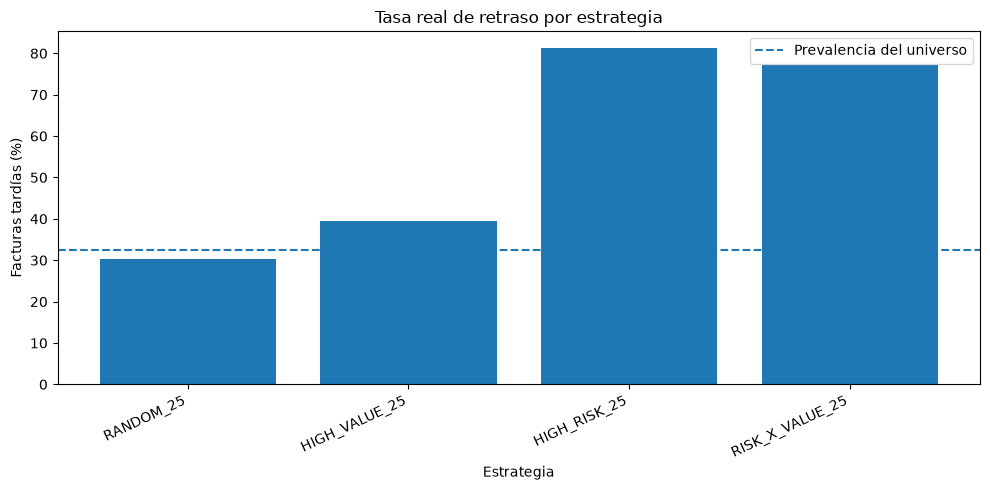

In [43]:
fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.bar(
    prioritization_summary[
        "strategy"
    ],
    prioritization_summary[
        "observed_late_rate"
    ] * 100
)

ax.axhline(
    primary_risk_treasury_universe[
        "late_payment"
    ].mean() * 100,
    linestyle="--",
    label="Prevalencia del universo"
)

ax.set_title(
    "Tasa real de retraso por estrategia"
)

ax.set_xlabel(
    "Estrategia"
)

ax.set_ylabel(
    "Facturas tardías (%)"
)

ax.legend()

plt.xticks(
    rotation=25,
    ha="right"
)

plt.tight_layout()
plt.show()

### Captura de retrasos reales

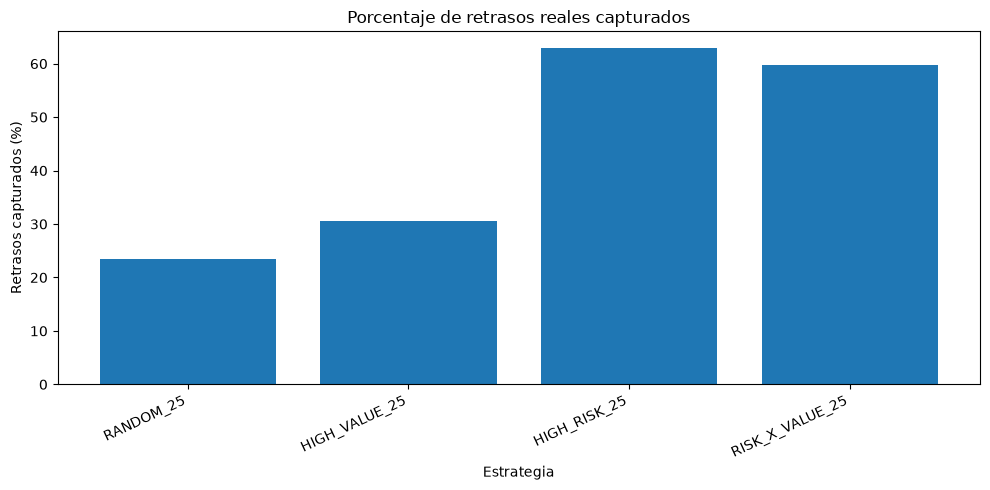

In [44]:
fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.bar(
    prioritization_summary[
        "strategy"
    ],
    prioritization_summary[
        "late_invoice_capture_pct"
    ] * 100
)

ax.set_title(
    "Porcentaje de retrasos reales capturados"
)

ax.set_xlabel(
    "Estrategia"
)

ax.set_ylabel(
    "Retrasos capturados (%)"
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.tight_layout()
plt.show()

### Exposicion monetaria

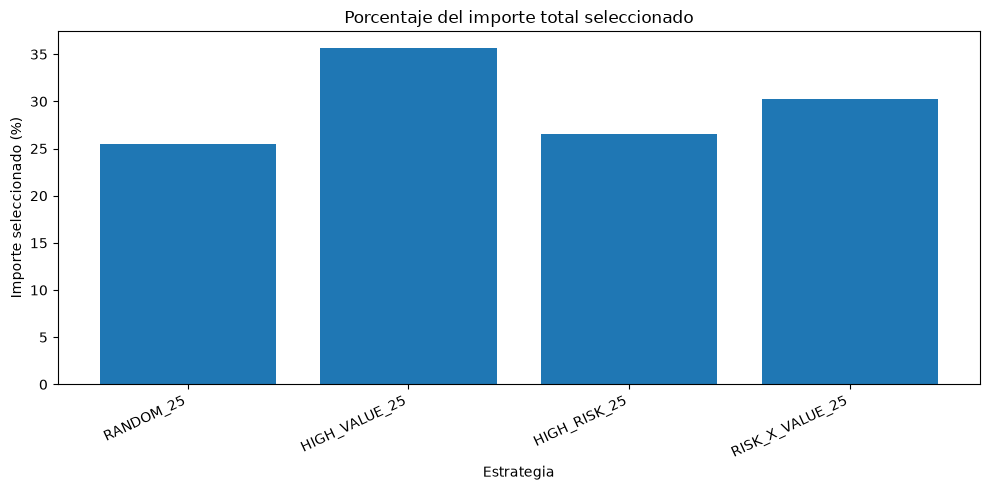

In [45]:
fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.bar(
    prioritization_summary[
        "strategy"
    ],
    prioritization_summary[
        "selected_amount_pct"
    ] * 100
)

ax.set_title(
    "Porcentaje del importe total seleccionado"
)

ax.set_xlabel(
    "Estrategia"
)

ax.set_ylabel(
    "Importe seleccionado (%)"
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.tight_layout()
plt.show()

### Overlap entre estrategias

In [46]:
strategy_selected_ids = {
    "RANDOM_25": set(
        random_25[
            "movement_id"
        ]
    ),

    "HIGH_VALUE_25": set(
        high_value_25[
            "movement_id"
        ]
    ),

    "HIGH_RISK_25": set(
        high_risk_25[
            "movement_id"
        ]
    ),

    "RISK_X_VALUE_25": set(
        risk_x_value_25[
            "movement_id"
        ]
    ),
}

### Matriz de interseccion

In [47]:
strategy_names = list(
    strategy_selected_ids.keys()
)

selection_overlap_count = pd.DataFrame(
    index=strategy_names,
    columns=strategy_names,
    dtype=int,
)

for strategy_a in strategy_names:
    for strategy_b in strategy_names:

        selection_overlap_count.loc[
            strategy_a,
            strategy_b
        ] = len(
            strategy_selected_ids[
                strategy_a
            ]
            &
            strategy_selected_ids[
                strategy_b
            ]
        )

selection_overlap_count

,RANDOM_25,HIGH_VALUE_25,HIGH_RISK_25,RISK_X_VALUE_25
RANDOM_25,96.0,27.0,31.0,30.0
HIGH_VALUE_25,27.0,96.0,31.0,44.0
HIGH_RISK_25,31.0,31.0,96.0,77.0
RISK_X_VALUE_25,30.0,44.0,77.0,96.0


### Porcentaje de solapamiento

In [48]:
selection_overlap_pct = (
    selection_overlap_count
    /
    PRIORITIZATION_COUNT
)

selection_overlap_pct

,RANDOM_25,HIGH_VALUE_25,HIGH_RISK_25,RISK_X_VALUE_25
RANDOM_25,1.000000,0.281250,0.322917,0.312500
HIGH_VALUE_25,0.281250,1.000000,0.322917,0.458333
HIGH_RISK_25,0.322917,0.322917,1.000000,0.802083
RISK_X_VALUE_25,0.312500,0.458333,0.802083,1.000000


### Jaccard entre estrategias

In [49]:
selection_jaccard = pd.DataFrame(
    index=strategy_names,
    columns=strategy_names,
    dtype=float,
)

for strategy_a in strategy_names:
    for strategy_b in strategy_names:

        intersection = len(
            strategy_selected_ids[
                strategy_a
            ]
            &
            strategy_selected_ids[
                strategy_b
            ]
        )

        union = len(
            strategy_selected_ids[
                strategy_a
            ]
            |
            strategy_selected_ids[
                strategy_b
            ]
        )

        selection_jaccard.loc[
            strategy_a,
            strategy_b
        ] = (
            intersection
            /
            union
        )

selection_jaccard

,RANDOM_25,HIGH_VALUE_25,HIGH_RISK_25,RISK_X_VALUE_25
RANDOM_25,1.000000,0.163636,0.192547,0.185185
HIGH_VALUE_25,0.163636,1.000000,0.192547,0.297297
HIGH_RISK_25,0.192547,0.192547,1.000000,0.669565
RISK_X_VALUE_25,0.185185,0.297297,0.669565,1.000000


### Cómo interpretar las estrategias

Las cuatro estrategias responden a preguntas diferentes.

### RANDOM 25

Representa una referencia sin información.

Si el modelo predictivo aporta valor, `HIGH_RISK_25` debería concentrar una proporción superior de retrasos reales.

### HIGH VALUE 25

Representa exposición financiera.

No intenta identificar qué facturas tienen mayor probabilidad de retrasarse.

Su objetivo es concentrar cobros cuyo desplazamiento podría tener una consecuencia monetaria elevada.

### HIGH RISK 25

Representa la señal predictiva pura.

Una tasa de retraso y un `late_invoice_capture_pct` elevados indicarían que el modelo es capaz de concentrar eventos adversos dentro de una fracción reducida de la cartera.

### RISK × VALUE 25

Combina las dos dimensiones anteriores.

Su objetivo no es maximizar necesariamente la tasa de retraso ni seleccionar exclusivamente las facturas más grandes.

Busca identificar operaciones donde coinciden:

- riesgo estimado relevante;
- importe económicamente significativo.

La utilidad final de cada estrategia no se decidirá únicamente con estas métricas.

En el siguiente bloque se trasladarán las cuatro selecciones al calendario diario de tesorería aplicando el mismo shock temporal de +10 días.

De esta forma será posible medir directamente su impacto sobre:

- saldo mínimo;
- deterioro máximo de liquidez;
- días negativos;
- necesidad potencial de financiación.

## Conclusiones de las estrategias de priorización

Las cuatro estrategias han seleccionado exactamente 96 facturas sobre un universo de 381 observaciones.

Esto representa aproximadamente el 25,2 % de la cartera analizada.

Al utilizar el mismo número de facturas en todos los casos, las diferencias observadas pueden atribuirse al criterio de priorización utilizado.

## Benchmark aleatorio

La selección aleatoria concentra aproximadamente:

- 25,4 % del importe total;
- 30,2 % de tasa real de retraso;
- 23,4 % de los retrasos reales;
- 23,6 % del importe correspondiente a facturas tardías.

Estos resultados funcionan como referencia inicial.

Una única muestra aleatoria puede presentar variabilidad, por lo que posteriormente se construirá un benchmark Monte Carlo antes de obtener conclusiones definitivas frente al azar.

## Priorización por importe

`HIGH_VALUE_25` concentra:

- 35,6 % del importe total;
- 39,6 % de tasa real de retraso;
- 30,6 % de los retrasos reales;
- 43,4 % del importe tardío.

La estrategia consigue concentrar exposición monetaria, pero su capacidad para identificar retrasos es limitada en comparación con el modelo predictivo.

Esto confirma que el importe de una factura y su probabilidad de retraso representan dimensiones diferentes.

## Priorización por riesgo predictivo

`HIGH_RISK_25` presenta la mayor concentración de eventos de retraso.

Las 96 facturas seleccionadas contienen:

- 78 de los 124 retrasos reales;
- una tasa real de retraso del 81,3 %;
- aproximadamente el 62,9 % de todas las facturas tardías;
- aproximadamente el 64,4 % del importe total asociado a facturas tardías.

La tasa de retraso del grupo seleccionado es aproximadamente 2,5 veces superior a la prevalencia general de la cartera.

Por tanto, el modelo predictivo demuestra una capacidad elevada para concentrar las facturas que posteriormente presentan retraso dentro de una fracción reducida del universo.

## Priorización combinada de riesgo y exposición

`RISK_X_VALUE_25` combina la probabilidad estimada de retraso con el importe de la factura.

La estrategia selecciona:

- 30,3 % del importe total;
- una tasa real de retraso del 77,1 %;
- 59,7 % de las facturas tardías;
- 67,9 % del importe correspondiente a facturas tardías.

Respecto a `HIGH_RISK_25`, la estrategia combinada captura ligeramente menos facturas tardías, pero concentra una proporción superior del importe monetario asociado a retrasos reales.

Esto refleja un trade-off entre:

`capacidad predictiva`

y

`exposición financiera`.

## Solapamiento entre estrategias

`HIGH_RISK_25` y `RISK_X_VALUE_25` comparten 77 de sus 96 facturas seleccionadas, aproximadamente el 80,2 %.

Por tanto, ambas estrategias están fuertemente relacionadas, aunque no son equivalentes.

La estrategia combinada sustituye parte de las facturas seleccionadas únicamente por riesgo por otras operaciones donde la combinación entre riesgo e importe es mayor.

Su solapamiento con `HIGH_VALUE_25` también es superior al observado entre `HIGH_VALUE_25` y `HIGH_RISK_25`.

Esto confirma que `RISK_X_VALUE_25` funciona como una estrategia híbrida entre riesgo predictivo y exposición monetaria.

## Interpretación

Los resultados muestran que el modelo predictivo aporta información que no está contenida únicamente en el importe de la factura.

Por otro lado, incorporar la exposición monetaria modifica de forma relevante la priorización cuando el objetivo no es solamente identificar retrasos, sino también concentrar el importe financiero potencialmente afectado.

Por tanto, las estrategias responden a objetivos distintos:

- `HIGH_RISK_25`: maximizar la concentración de facturas con mayor riesgo de retraso;
- `HIGH_VALUE_25`: concentrar exposición monetaria;
- `RISK_X_VALUE_25`: combinar ambas dimensiones.

El siguiente paso será trasladar estas mismas selecciones al calendario diario de tesorería.

Todas las estrategias recibirán el mismo shock adicional de 10 días.

Esto permitirá determinar si las diferencias observadas en capacidad predictiva y exposición se traducen también en diferencias reales sobre la liquidez disponible.

## 7. Impacto de las estrategias de priorización sobre la tesorería

Las estrategias anteriores identifican diferentes subconjuntos de 96 facturas.

El siguiente paso consiste en trasladar esas selecciones al calendario de tesorería.

A todas las facturas seleccionadas se les aplicará exactamente el mismo shock:

`+10 días adicionales sobre su fecha real de cobro`

Por tanto, las diferencias entre escenarios dependerán exclusivamente de qué facturas hayan sido priorizadas.

Se compararán:

- `BASE`;
- `RANDOM_25`;
- `HIGH_VALUE_25`;
- `HIGH_RISK_25`;
- `RISK_X_VALUE_25`.

## Variables que permanecerán constantes

No se modificarán:

- importes de las facturas;
- pagos a proveedores;
- gastos recurrentes;
- impuestos;
- financiación;
- saldo inicial;
- movimientos no seleccionados.

Los 10 días representan días naturales y no se realizará un ajuste adicional por fines de semana.

## Interpretación del shock

El escenario no pretende afirmar que las facturas seleccionadas vayan a retrasarse exactamente 10 días.

Se trata de un experimento contrafactual:

> ¿qué efecto tendría sobre la liquidez un deterioro adicional idéntico aplicado a las facturas priorizadas por cada estrategia?

## Ventana de impacto

El mínimo histórico de tesorería del escenario base se produce en marzo de 2012.

Sin embargo, las facturas utilizadas en la integración predictiva pertenecen a `VALIDATION_OOS`, durante 2013.

Por tanto, utilizar únicamente el saldo mínimo de todo el horizonte podría ocultar el efecto de los escenarios, ya que un mínimo ocurrido antes de las facturas analizadas permanecería inalterado.

Se definirá una ventana específica de impacto que comienza con el primer cobro del universo principal y termina 10 días después del último cobro.

Las métricas financieras principales se calcularán dentro de esta ventana común.

### Parametros del escenario

In [50]:
SELECTIVE_STRESS_DAYS = 10

simulation_start_date = pd.Timestamp(
    simulation_metadata[
        "simulation_start_date"
    ]
)

simulation_end_date = pd.Timestamp(
    simulation_metadata[
        "simulation_end_date"
    ]
)

initial_cash_balance = float(
    simulation_metadata[
        "initial_cash_balance"
    ]
)

daily_cashflow[
    "date"
] = pd.to_datetime(
    daily_cashflow[
        "date"
    ]
).dt.normalize()

### Ventana de impacto OOS

In [51]:
impact_window_start = (
    primary_risk_treasury_universe[
        "receipt_date"
    ].min()
)

impact_window_end = (
    primary_risk_treasury_universe[
        "receipt_date"
    ].max()
    +
    pd.Timedelta(
        days=SELECTIVE_STRESS_DAYS
    )
)

impact_window_end = min(
    impact_window_end,
    simulation_end_date
)

impact_window_summary = pd.Series({
    "impact_window_start": (
        impact_window_start
    ),

    "impact_window_end": (
        impact_window_end
    ),

    "impact_window_days": (
        (
            impact_window_end
            -
            impact_window_start
        ).days
        + 1
    ),

    "stress_days": (
        SELECTIVE_STRESS_DAYS
    ),
})

impact_window_summary

C:\Users\jesus\AppData\Local\Temp\ipykernel_30736\1711607286.py:12: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  pd.Timedelta(


impact_window_start    2013-05-09 00:00:00
impact_window_end      2013-10-10 00:00:00
impact_window_days                     155
stress_days                             10
dtype: object

### Validar IDs seleccionados

In [52]:
real_customer_receipt_ids = set(
    cash_movements.loc[
        cash_movements[
            "direction"
        ].eq(
            "CASH_IN"
        )
        &
        cash_movements[
            "movement_type"
        ].eq(
            "CUSTOMER_RECEIPT"
        )
        &
        cash_movements[
            "data_origin"
        ].eq(
            "REAL"
        ),
        "movement_id"
    ]
)

for (
    strategy_name,
    selected_ids
) in strategy_selected_ids.items():

    assert (
        len(
            selected_ids
        )
        ==
        PRIORITIZATION_COUNT
    )

    assert selected_ids.issubset(
        real_customer_receipt_ids
    )

print(
    "✓ Las cuatro estrategias contienen "
    "96 cobros reales válidos."
)

✓ Las cuatro estrategias contienen 96 cobros reales válidos.


### Motor de reconstrucción de tesorería

Los escenarios se construirán a partir de copias de `cash_movements`.

Después de modificar únicamente las fechas de los cobros seleccionados, se reconstruirá desde cero la serie diaria de tesorería.

Antes de utilizar el motor se comprobará que, sin modificar movimientos, reproduce exactamente `gold_daily_cashflow.parquet`.

### Funcion para construir cashflow diario

In [53]:
def build_daily_cashflow(
    movements,
    initial_cash,
    start_date,
    end_date,
):
    movements = (
        movements
        .copy()
    )

    movements[
        "date"
    ] = pd.to_datetime(
        movements[
            "date"
        ]
    ).dt.normalize()

    calendar = pd.DataFrame({
        "date": pd.date_range(
            start=start_date,
            end=end_date,
            freq="D",
        )
    })

    daily_in = (
        movements.loc[
            movements[
                "direction"
            ].eq(
                "CASH_IN"
            )
        ]
        .groupby(
            "date"
        )[
            "amount"
        ]
        .sum()
    )

    daily_out = (
        movements.loc[
            movements[
                "direction"
            ].eq(
                "CASH_OUT"
            )
        ]
        .groupby(
            "date"
        )[
            "amount"
        ]
        .sum()
    )

    movement_count = (
        movements
        .groupby(
            "date"
        )[
            "movement_id"
        ]
        .count()
    )

    calendar[
        "cash_in"
    ] = (
        calendar[
            "date"
        ]
        .map(
            daily_in
        )
        .fillna(0.0)
    )

    calendar[
        "cash_out"
    ] = (
        calendar[
            "date"
        ]
        .map(
            daily_out
        )
        .fillna(0.0)
    )

    calendar[
        "movement_count"
    ] = (
        calendar[
            "date"
        ]
        .map(
            movement_count
        )
        .fillna(0)
        .astype(int)
    )

    calendar[
        "net_cashflow"
    ] = (
        calendar[
            "cash_in"
        ]
        -
        calendar[
            "cash_out"
        ]
    )

    calendar[
        "cumulative_net_cashflow"
    ] = (
        calendar[
            "net_cashflow"
        ]
        .cumsum()
    )

    calendar[
        "closing_cash_balance"
    ] = (
        initial_cash
        +
        calendar[
            "cumulative_net_cashflow"
        ]
    )

    calendar[
        "opening_cash_balance"
    ] = (
        calendar[
            "closing_cash_balance"
        ]
        .shift(1)
    )

    calendar.loc[
        0,
        "opening_cash_balance"
    ] = initial_cash

    return calendar[
        [
            "date",
            "opening_cash_balance",
            "cash_in",
            "cash_out",
            "net_cashflow",
            "closing_cash_balance",
            "cumulative_net_cashflow",
            "movement_count",
        ]
    ]

### Validar motor contra escenario base

In [54]:
reconstructed_base = (
    build_daily_cashflow(
        movements=cash_movements,
        initial_cash=initial_cash_balance,
        start_date=simulation_start_date,
        end_date=simulation_end_date,
    )
)

assert np.allclose(
    reconstructed_base[
        "cash_in"
    ],
    daily_cashflow[
        "cash_in"
    ]
)

assert np.allclose(
    reconstructed_base[
        "cash_out"
    ],
    daily_cashflow[
        "cash_out"
    ]
)

assert np.allclose(
    reconstructed_base[
        "closing_cash_balance"
    ],
    daily_cashflow[
        "closing_cash_balance"
    ]
)

print(
    "✓ El motor reproduce exactamente "
    "el escenario base."
)

✓ El motor reproduce exactamente el escenario base.


### Funcion para retrasar unicamente cobros seleccionados

In [55]:
def create_prioritization_stress_scenario(
    movements,
    selected_movement_ids,
    delay_days,
):
    scenario_movements = (
        movements
        .copy()
    )

    scenario_movements[
        "original_date"
    ] = (
        scenario_movements[
            "date"
        ]
    )

    selected_mask = (
        scenario_movements[
            "movement_id"
        ].isin(
            selected_movement_ids
        )
    )

    scenario_movements[
        "delayed_in_scenario"
    ] = (
        selected_mask
    )

    scenario_movements[
        "scenario_delay_days"
    ] = np.where(
        selected_mask,
        delay_days,
        0,
    )

    scenario_movements.loc[
        selected_mask,
        "date"
    ] = (
        scenario_movements.loc[
            selected_mask,
            "date"
        ]
        +
        pd.to_timedelta(
            delay_days,
            unit="D",
        )
    )

    scenario_movements[
        "date"
    ] = pd.to_datetime(
        scenario_movements[
            "date"
        ]
    ).dt.normalize()

    return scenario_movements

### Validar funcion con seleccion vacia

In [56]:
zero_stress_test = (
    create_prioritization_stress_scenario(
        movements=cash_movements,
        selected_movement_ids=set(),
        delay_days=SELECTIVE_STRESS_DAYS,
    )
)

assert (
    zero_stress_test[
        "date"
    ]
    .reset_index(
        drop=True
    )
    ==
    cash_movements[
        "date"
    ]
    .reset_index(
        drop=True
    )
).all()

assert (
    zero_stress_test[
        "delayed_in_scenario"
    ].sum()
    == 0
)

print(
    "✓ Función de estrés selectivo validada."
)

✓ Función de estrés selectivo validada.


### Definir escenarios

In [57]:
treasury_strategy_specs = {
    "BASE": {
        "strategy": "BASE",
        "selected_ids": set(),
        "delay_days": 0,
    },

    "RANDOM_25_DELAY_10": {
        "strategy": "RANDOM_25",
        "selected_ids": (
            strategy_selected_ids[
                "RANDOM_25"
            ]
        ),
        "delay_days": (
            SELECTIVE_STRESS_DAYS
        ),
    },

    "HIGH_VALUE_25_DELAY_10": {
        "strategy": "HIGH_VALUE_25",
        "selected_ids": (
            strategy_selected_ids[
                "HIGH_VALUE_25"
            ]
        ),
        "delay_days": (
            SELECTIVE_STRESS_DAYS
        ),
    },

    "HIGH_RISK_25_DELAY_10": {
        "strategy": "HIGH_RISK_25",
        "selected_ids": (
            strategy_selected_ids[
                "HIGH_RISK_25"
            ]
        ),
        "delay_days": (
            SELECTIVE_STRESS_DAYS
        ),
    },

    "RISK_X_VALUE_25_DELAY_10": {
        "strategy": "RISK_X_VALUE_25",
        "selected_ids": (
            strategy_selected_ids[
                "RISK_X_VALUE_25"
            ]
        ),
        "delay_days": (
            SELECTIVE_STRESS_DAYS
        ),
    },
}

### Funcion de metricas basicas

In [58]:
def calculate_treasury_scenario_metrics(
    daily_df,
    scenario_name,
    strategy_name,
):
    full_minimum_idx = (
        daily_df[
            "closing_cash_balance"
        ]
        .idxmin()
    )

    impact_df = (
        daily_df[
            daily_df[
                "date"
            ].between(
                impact_window_start,
                impact_window_end,
            )
        ]
        .copy()
    )

    impact_minimum_idx = (
        impact_df[
            "closing_cash_balance"
        ]
        .idxmin()
    )

    negative_mask = (
        daily_df[
            "closing_cash_balance"
        ] < 0
    )

    return {
        "scenario": (
            scenario_name
        ),

        "strategy": (
            strategy_name
        ),

        "total_cash_in": (
            daily_df[
                "cash_in"
            ].sum()
        ),

        "total_cash_out": (
            daily_df[
                "cash_out"
            ].sum()
        ),

        "net_cashflow": (
            daily_df[
                "net_cashflow"
            ].sum()
        ),

        "full_horizon_minimum_balance": (
            daily_df[
                "closing_cash_balance"
            ].min()
        ),

        "full_horizon_minimum_date": (
            daily_df.loc[
                full_minimum_idx,
                "date"
            ]
        ),

        "impact_window_minimum_balance": (
            impact_df[
                "closing_cash_balance"
            ].min()
        ),

        "impact_window_minimum_date": (
            daily_df.loc[
                impact_minimum_idx,
                "date"
            ]
        ),

        "impact_window_average_balance": (
            impact_df[
                "closing_cash_balance"
            ].mean()
        ),

        "negative_cash_days": (
            negative_mask.sum()
        ),

        "maximum_funding_gap": (
            max(
                0.0,
                -daily_df[
                    "closing_cash_balance"
                ].min()
            )
        ),

        "final_balance": (
            daily_df[
                "closing_cash_balance"
            ].iloc[-1]
        ),
    }

### Ejecutar los cinco escenarios

In [59]:
treasury_strategy_movements = {}

treasury_strategy_daily = {}

treasury_strategy_rows = []

for (
    scenario_name,
    spec
) in treasury_strategy_specs.items():

    scenario_movements = (
        create_prioritization_stress_scenario(
            movements=cash_movements,
            selected_movement_ids=spec[
                "selected_ids"
            ],
            delay_days=spec[
                "delay_days"
            ],
        )
    )

    selected_deferred_mask = (
        scenario_movements[
            "movement_id"
        ].isin(
            spec[
                "selected_ids"
            ]
        )
        &
        (
            scenario_movements[
                "date"
            ]
            > simulation_end_date
        )
    )

    deferred_receipt_count = (
        selected_deferred_mask.sum()
    )

    deferred_receipt_amount = (
        scenario_movements.loc[
            selected_deferred_mask,
            "amount"
        ].sum()
    )

    movements_inside_horizon = (
        scenario_movements[
            scenario_movements[
                "date"
            ].between(
                simulation_start_date,
                simulation_end_date,
            )
        ]
        .copy()
    )

    scenario_daily = (
        build_daily_cashflow(
            movements=movements_inside_horizon,
            initial_cash=initial_cash_balance,
            start_date=simulation_start_date,
            end_date=simulation_end_date,
        )
    )

    scenario_metrics = (
        calculate_treasury_scenario_metrics(
            daily_df=scenario_daily,
            scenario_name=scenario_name,
            strategy_name=spec[
                "strategy"
            ],
        )
    )

    scenario_metrics.update({
        "selected_receipt_count": (
            len(
                spec[
                    "selected_ids"
                ]
            )
        ),

        "delay_days": (
            spec[
                "delay_days"
            ]
        ),

        "deferred_receipt_count": (
            deferred_receipt_count
        ),

        "deferred_receipt_amount": (
            deferred_receipt_amount
        ),
    })

    treasury_strategy_movements[
        scenario_name
    ] = scenario_movements

    treasury_strategy_daily[
        scenario_name
    ] = scenario_daily

    treasury_strategy_rows.append(
        scenario_metrics
    )

### Validar que solo cambian los cobros seleccionados

In [60]:
base_movements_indexed = (
    cash_movements
    .set_index(
        "movement_id"
    )
    .sort_index()
)

for (
    scenario_name,
    spec
) in treasury_strategy_specs.items():

    scenario_indexed = (
        treasury_strategy_movements[
            scenario_name
        ]
        .set_index(
            "movement_id"
        )
        .sort_index()
    )

    selected_ids = (
        spec[
            "selected_ids"
        ]
    )

    selected_mask = (
        base_movements_indexed
        .index
        .isin(
            selected_ids
        )
    )

    assert scenario_indexed.index.equals(
        base_movements_indexed.index
    )

    assert np.allclose(
        scenario_indexed[
            "amount"
        ],
        base_movements_indexed[
            "amount"
        ]
    )

    assert (
        scenario_indexed.loc[
            ~selected_mask,
            "date"
        ]
        ==
        base_movements_indexed.loc[
            ~selected_mask,
            "date"
        ]
    ).all()

    if selected_mask.any():

        expected_dates = (
            base_movements_indexed.loc[
                selected_mask,
                "date"
            ]
            +
            pd.to_timedelta(
                spec[
                    "delay_days"
                ],
                unit="D",
            )
        )

        assert (
            scenario_indexed.loc[
                selected_mask,
                "date"
            ]
            ==
            expected_dates
        ).all()

print(
    "✓ Solo cambian las fechas de los "
    "cobros seleccionados."
)

✓ Solo cambian las fechas de los cobros seleccionados.


### Validar salidas constantes

In [61]:
base_cash_out = (
    daily_cashflow[
        "cash_out"
    ].sum()
)

for (
    scenario_name,
    scenario_daily
) in treasury_strategy_daily.items():

    assert np.isclose(
        scenario_daily[
            "cash_out"
        ].sum(),
        base_cash_out
    )

print(
    "✓ Las salidas de caja permanecen "
    "constantes en todos los escenarios."
)

✓ Las salidas de caja permanecen constantes en todos los escenarios.


### Construir tabla inicial

In [62]:
treasury_strategy_summary = (
    pd.DataFrame(
        treasury_strategy_rows
    )
)

treasury_strategy_summary

,scenario,strategy,total_cash_in,total_cash_out,net_cashflow,full_horizon_minimum_balance,full_horizon_minimum_date,impact_window_minimum_balance,impact_window_minimum_date,impact_window_average_balance,negative_cash_days,maximum_funding_gap,final_balance,selected_receipt_count,delay_days,deferred_receipt_count,deferred_receipt_amount
0,BASE,BASE,141713.03,106139.47,35573.56,6865.132045,2012-03-02,31875.222045,2013-05-10,36906.440884,0,0.0,42810.342045,0,0,0,0.0
1,RANDOM_25_DELAY_10,RANDOM_25,141713.03,106139.47,35573.56,6865.132045,2012-03-02,31875.222045,2013-05-10,36530.254433,0,0.0,42810.342045,96,10,0,0.0
2,HIGH_VALUE_25_DELAY_10,HIGH_VALUE_25,141713.03,106139.47,35573.56,6865.132045,2012-03-02,31830.502045,2013-05-16,36379.260884,0,0.0,42810.342045,96,10,0,0.0
3,HIGH_RISK_25_DELAY_10,HIGH_RISK_25,141713.03,106139.47,35573.56,6865.132045,2012-03-02,31875.222045,2013-05-10,36513.481529,0,0.0,42810.342045,96,10,0,0.0
4,RISK_X_VALUE_25_DELAY_10,RISK_X_VALUE_25,141713.03,106139.47,35573.56,6865.132045,2012-03-02,31875.222045,2013-05-10,36458.855723,0,0.0,42810.342045,96,10,0,0.0


### Construir deterioro respecto a BASE

In [63]:
base_daily_balance = (
    treasury_strategy_daily[
        "BASE"
    ][
        "closing_cash_balance"
    ]
    .to_numpy()
)

impact_mask = (
    treasury_strategy_daily[
        "BASE"
    ][
        "date"
    ].between(
        impact_window_start,
        impact_window_end,
    )
    .to_numpy()
)

maximum_deterioration = {}
maximum_deterioration_date = {}

average_deterioration = {}

liquidity_gap_amount_days = {}

days_with_lower_liquidity = {}

for (
    scenario_name,
    scenario_daily
) in treasury_strategy_daily.items():

    deterioration = (
        base_daily_balance
        -
        scenario_daily[
            "closing_cash_balance"
        ].to_numpy()
    )

    impact_deterioration = (
        deterioration[
            impact_mask
        ]
    )

    impact_dates = (
        scenario_daily.loc[
            impact_mask,
            "date"
        ]
        .reset_index(
            drop=True
        )
    )

    max_position = int(
        np.argmax(
            impact_deterioration
        )
    )

    maximum_deterioration[
        scenario_name
    ] = float(
        impact_deterioration[
            max_position
        ]
    )

    maximum_deterioration_date[
        scenario_name
    ] = (
        impact_dates.iloc[
            max_position
        ]
    )

    average_deterioration[
        scenario_name
    ] = float(
        impact_deterioration.mean()
    )

    liquidity_gap_amount_days[
        scenario_name
    ] = float(
        impact_deterioration.sum()
    )

    days_with_lower_liquidity[
        scenario_name
    ] = int(
        (
            impact_deterioration
            > 1e-9
        ).sum()
    )

In [64]:
for (
    scenario_name,
    scenario_daily
) in treasury_strategy_daily.items():

    deterioration = (
        treasury_strategy_daily[
            "BASE"
        ][
            "closing_cash_balance"
        ].to_numpy()
        -
        scenario_daily[
            "closing_cash_balance"
        ].to_numpy()
    )

    assert (
        deterioration
        >= -1e-9
    ).all()

print(
    "✓ Ningún escenario de retraso "
    "mejora artificialmente la liquidez frente a BASE."
)

✓ Ningún escenario de retraso mejora artificialmente la liquidez frente a BASE.


### Añadir metricas a la tabla

In [65]:
treasury_strategy_summary[
    "maximum_liquidity_deterioration"
] = (
    treasury_strategy_summary[
        "scenario"
    ]
    .map(
        maximum_deterioration
    )
)

treasury_strategy_summary[
    "maximum_deterioration_date"
] = (
    treasury_strategy_summary[
        "scenario"
    ]
    .map(
        maximum_deterioration_date
    )
)

treasury_strategy_summary[
    "average_liquidity_deterioration"
] = (
    treasury_strategy_summary[
        "scenario"
    ]
    .map(
        average_deterioration
    )
)

treasury_strategy_summary[
    "liquidity_gap_amount_days"
] = (
    treasury_strategy_summary[
        "scenario"
    ]
    .map(
        liquidity_gap_amount_days
    )
)

treasury_strategy_summary[
    "days_with_lower_liquidity"
] = (
    treasury_strategy_summary[
        "scenario"
    ]
    .map(
        days_with_lower_liquidity
    )
)

### Cambio del minimo en la ventana

In [66]:
base_impact_minimum = (
    treasury_strategy_summary.loc[
        treasury_strategy_summary[
            "scenario"
        ].eq(
            "BASE"
        ),
        "impact_window_minimum_balance"
    ]
    .iloc[0]
)

base_final_balance = (
    treasury_strategy_summary.loc[
        treasury_strategy_summary[
            "scenario"
        ].eq(
            "BASE"
        ),
        "final_balance"
    ]
    .iloc[0]
)

treasury_strategy_summary[
    "impact_minimum_change_vs_base"
] = (
    treasury_strategy_summary[
        "impact_window_minimum_balance"
    ]
    -
    base_impact_minimum
)

treasury_strategy_summary[
    "impact_minimum_reduction_pct"
] = (
    (
        base_impact_minimum
        -
        treasury_strategy_summary[
            "impact_window_minimum_balance"
        ]
    )
    /
    base_impact_minimum
)

treasury_strategy_summary[
    "final_balance_change_vs_base"
] = (
    treasury_strategy_summary[
        "final_balance"
    ]
    -
    base_final_balance
)

### Limpiar fecha BASE

In [67]:
treasury_strategy_summary.loc[
    treasury_strategy_summary[
        "scenario"
    ].eq(
        "BASE"
    ),
    "maximum_deterioration_date"
] = pd.NaT

### Tabla comparativa principal

In [68]:
treasury_strategy_comparison = (
    treasury_strategy_summary[
        [
            "scenario",
            "strategy",
            "selected_receipt_count",
            "delay_days",
            "impact_window_minimum_balance",
            "impact_window_minimum_date",
            "impact_minimum_reduction_pct",
            "maximum_liquidity_deterioration",
            "maximum_deterioration_date",
            "average_liquidity_deterioration",
            "days_with_lower_liquidity",
            "liquidity_gap_amount_days",
            "negative_cash_days",
            "maximum_funding_gap",
            "deferred_receipt_count",
            "deferred_receipt_amount",
            "final_balance",
        ]
    ]
    .copy()
)

treasury_strategy_comparison

,scenario,strategy,selected_receipt_count,delay_days,impact_window_minimum_balance,impact_window_minimum_date,impact_minimum_reduction_pct,maximum_liquidity_deterioration,maximum_deterioration_date,average_liquidity_deterioration,days_with_lower_liquidity,liquidity_gap_amount_days,negative_cash_days,maximum_funding_gap,deferred_receipt_count,deferred_receipt_amount,final_balance
0,BASE,BASE,0,0,31875.222045,2013-05-10,0.000000,0.00,NaT,0.000000,0,0.0,0,0.0,0,0.0,42810.342045
1,RANDOM_25_DELAY_10,RANDOM_25,96,10,31875.222045,2013-05-10,0.000000,841.40,2013-07-05,376.186452,148,58308.9,0,0.0,0,0.0,42810.342045
2,HIGH_VALUE_25_DELAY_10,HIGH_VALUE_25,96,10,31830.502045,2013-05-16,0.001403,1175.50,2013-06-15,527.180000,133,81712.9,0,0.0,0,0.0,42810.342045
3,HIGH_RISK_25_DELAY_10,HIGH_RISK_25,96,10,31875.222045,2013-05-10,0.000000,807.71,2013-07-31,392.959355,129,60908.7,0,0.0,0,0.0,42810.342045
4,RISK_X_VALUE_25_DELAY_10,RISK_X_VALUE_25,96,10,31875.222045,2013-05-10,0.000000,1083.31,2013-09-02,447.585161,129,69375.7,0,0.0,0,0.0,42810.342045


### Validar cobros fuera del horizonte

In [69]:
for _, row in (
    treasury_strategy_summary
    .iterrows()
):

    assert np.isclose(
        row[
            "final_balance_change_vs_base"
        ],
        -row[
            "deferred_receipt_amount"
        ],
        atol=0.01,
    )

print(
    "✓ Las diferencias de saldo final "
    "se explican por cobros diferidos."
)

✓ Las diferencias de saldo final se explican por cobros diferidos.


### Validacion especifica del horizonte OOS

In [70]:
stress_scenarios_only = (
    treasury_strategy_summary[
        ~treasury_strategy_summary[
            "scenario"
        ].eq(
            "BASE"
        )
    ]
)

assert (
    stress_scenarios_only[
        "deferred_receipt_count"
    ]
    == 0
).all()

assert np.allclose(
    stress_scenarios_only[
        "deferred_receipt_amount"
    ],
    0.0,
)

print(
    "✓ Todos los cobros retrasados "
    "siguen dentro del horizonte."
)

✓ Todos los cobros retrasados siguen dentro del horizonte.


### Interpretación de las métricas de liquidez

El saldo mínimo de todo el horizonte se mantiene como control, pero no será la métrica principal de esta comparación.

Las estrategias modifican facturas de 2013, mientras que el mínimo histórico del escenario base se produjo en 2012.

El saldo mínimo dentro de la ventana se mantendrá como métrica descriptiva.

Sin embargo, no será la métrica principal para comparar estrategias, ya que puede estar determinado por un mínimo ocurrido antes de que los cobros seleccionados produzcan su mayor efecto.

La métrica principal será `maximum_liquidity_deterioration`, que mide directamente la mayor diferencia diaria de caja frente al escenario base.

### Visualizar saldos en la ventana de impacto

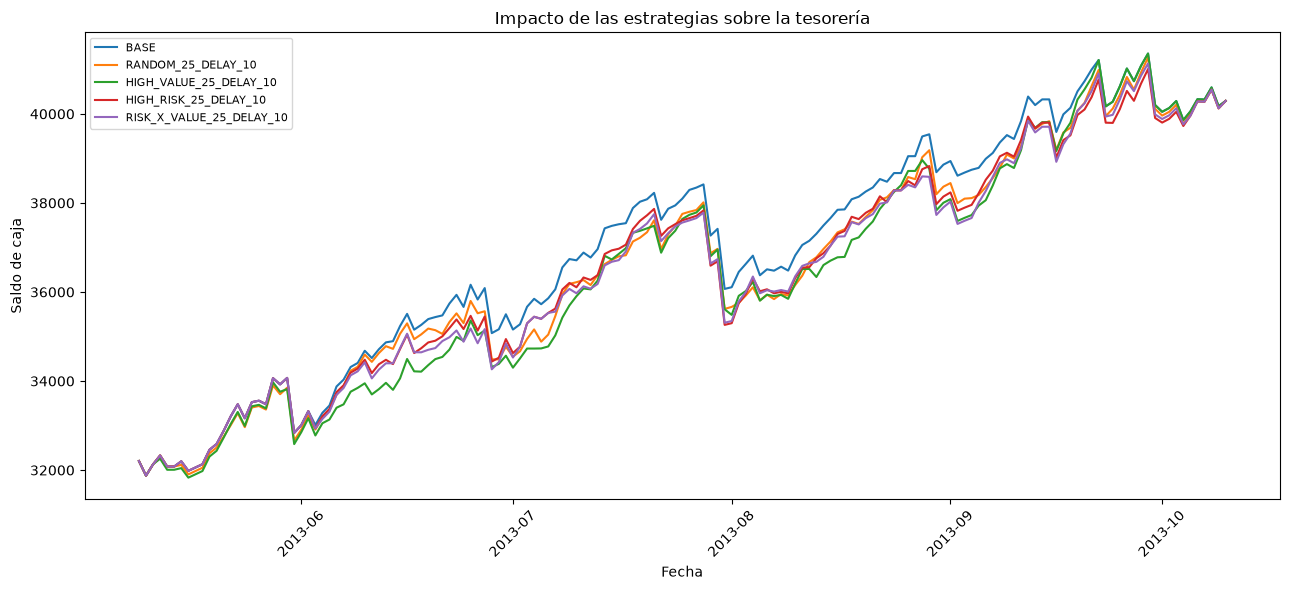

In [71]:
fig, ax = plt.subplots(
    figsize=(13, 6)
)

for (
    scenario_name,
    scenario_daily
) in treasury_strategy_daily.items():

    impact_df = (
        scenario_daily[
            scenario_daily[
                "date"
            ].between(
                impact_window_start,
                impact_window_end,
            )
        ]
    )

    ax.plot(
        impact_df[
            "date"
        ],
        impact_df[
            "closing_cash_balance"
        ],
        label=scenario_name,
    )

ax.set_title(
    "Impacto de las estrategias sobre la tesorería"
)

ax.set_xlabel(
    "Fecha"
)

ax.set_ylabel(
    "Saldo de caja"
)

ax.legend(
    fontsize=8
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()

### Visualizar deterioro frente a BASE

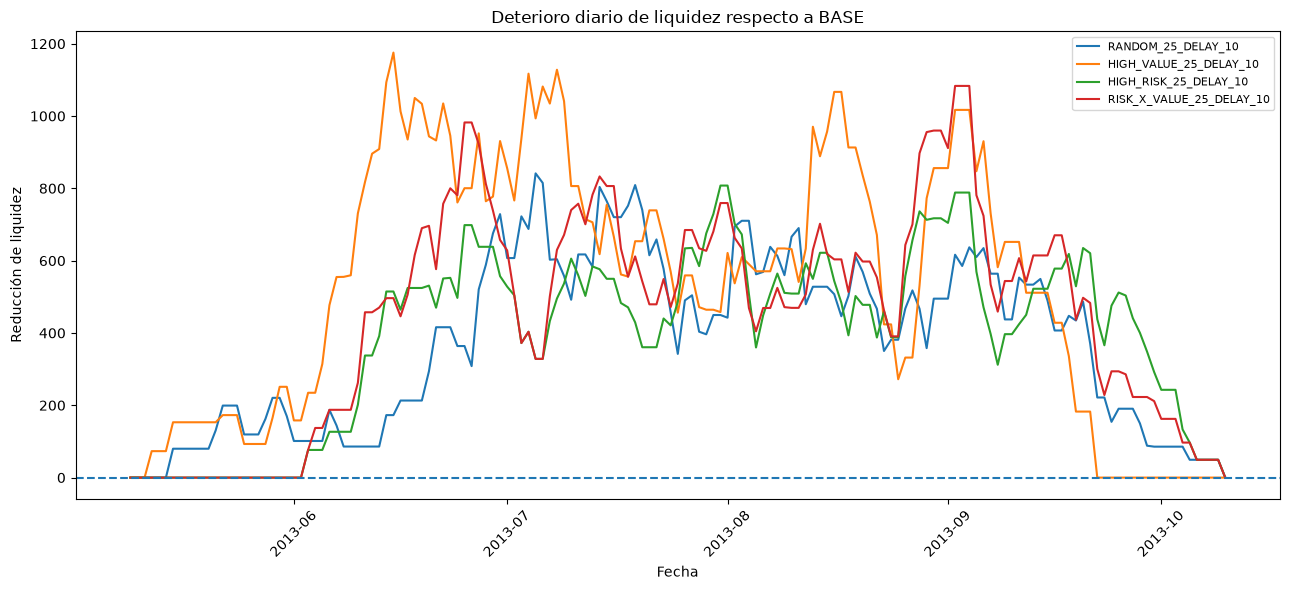

In [72]:
fig, ax = plt.subplots(
    figsize=(13, 6)
)

base_daily = (
    treasury_strategy_daily[
        "BASE"
    ]
)

for (
    scenario_name,
    scenario_daily
) in treasury_strategy_daily.items():

    if scenario_name == "BASE":
        continue

    deterioration = (
        base_daily[
            "closing_cash_balance"
        ]
        -
        scenario_daily[
            "closing_cash_balance"
        ]
    )

    impact_dates = (
        scenario_daily.loc[
            impact_mask,
            "date"
        ]
    )

    ax.plot(
        impact_dates,
        deterioration.loc[
            impact_mask
        ],
        label=scenario_name,
    )

ax.axhline(
    0,
    linestyle="--"
)

ax.set_title(
    "Deterioro diario de liquidez respecto a BASE"
)

ax.set_xlabel(
    "Fecha"
)

ax.set_ylabel(
    "Reducción de liquidez"
)

ax.legend(
    fontsize=8
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()

### Comparar deterioro maximo

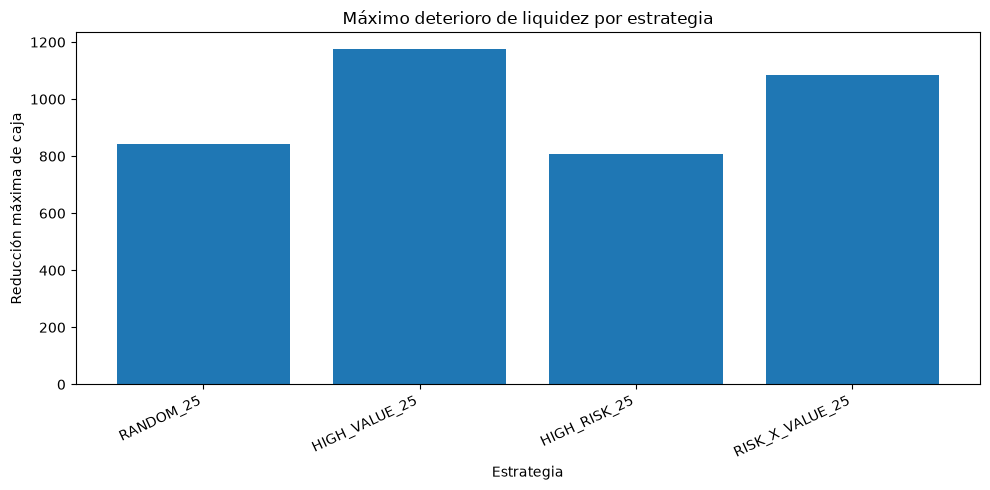

In [73]:
stress_treasury_comparison = (
    treasury_strategy_comparison[
        ~treasury_strategy_comparison[
            "strategy"
        ].eq(
            "BASE"
        )
    ]
    .copy()
)

fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.bar(
    stress_treasury_comparison[
        "strategy"
    ],
    stress_treasury_comparison[
        "maximum_liquidity_deterioration"
    ]
)

ax.set_title(
    "Máximo deterioro de liquidez por estrategia"
)

ax.set_xlabel(
    "Estrategia"
)

ax.set_ylabel(
    "Reducción máxima de caja"
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.tight_layout()

plt.show()

### Combinar resultados predictivos y financieros

In [74]:
integrated_strategy_comparison = (
    prioritization_summary
    .merge(
        treasury_strategy_summary[
            [
                "strategy",
                "impact_window_minimum_balance",
                "impact_minimum_reduction_pct",
                "maximum_liquidity_deterioration",
                "average_liquidity_deterioration",
                "days_with_lower_liquidity",
                "liquidity_gap_amount_days",
                "negative_cash_days",
            ]
        ],
        on="strategy",
        how="inner",
        validate="one_to_one",
    )
)

integrated_strategy_comparison[
    [
        "strategy",
        "selected_amount_pct",
        "observed_late_rate",
        "late_rate_lift",
        "late_invoice_capture_pct",
        "late_amount_capture_pct",
        "impact_window_minimum_balance",
        "maximum_liquidity_deterioration",
        "average_liquidity_deterioration",
        "days_with_lower_liquidity",
        "liquidity_gap_amount_days",
    ]
]

,strategy,selected_amount_pct,observed_late_rate,late_rate_lift,late_invoice_capture_pct,late_amount_capture_pct,impact_window_minimum_balance,maximum_liquidity_deterioration,average_liquidity_deterioration,days_with_lower_liquidity,liquidity_gap_amount_days
0,RANDOM_25,0.254355,0.302083,0.928175,0.233871,0.235801,31875.222045,841.40,376.186452,148,58308.9
1,HIGH_VALUE_25,0.356448,0.395833,1.216230,0.306452,0.433789,31830.502045,1175.50,527.180000,133,81712.9
2,HIGH_RISK_25,0.265696,0.812500,2.496472,0.629032,0.643818,31875.222045,807.71,392.959355,129,60908.7
3,RISK_X_VALUE_25,0.302631,0.770833,2.368448,0.596774,0.678562,31875.222045,1083.31,447.585161,129,69375.7


In [75]:
stress_integrated = (
    integrated_strategy_comparison.copy()
)

expected_amount_days = (
    stress_integrated[
        "selected_amount"
    ]
    *
    SELECTIVE_STRESS_DAYS
)

assert np.allclose(
    stress_integrated[
        "liquidity_gap_amount_days"
    ],
    expected_amount_days
)

print(
    "✓ Con un retraso fijo y sin cobros fuera "
    "del horizonte, liquidity_gap_amount_days "
    "equivale a importe seleccionado × días."
)

✓ Con un retraso fijo y sin cobros fuera del horizonte, liquidity_gap_amount_days equivale a importe seleccionado × días.


En este experimento todas las facturas seleccionadas reciben exactamente el mismo retraso de 10 días y permanecen dentro del horizonte.

Por tanto, `liquidity_gap_amount_days` está determinado directamente por:

`importe seleccionado × 10 días`

Esta métrica representa correctamente la exposición temporal acumulada, pero no aporta una dimensión independiente del importe en este escenario.

Para analizar el efecto específico del calendario se utilizará principalmente `maximum_liquidity_deterioration`.

## Conclusiones del impacto sobre tesorería

Las cuatro estrategias de priorización se han trasladado al calendario diario de tesorería aplicando el mismo deterioro contrafactual:

`+10 días sobre la fecha real de cobro`

Cada estrategia afecta exactamente a 96 facturas y mantiene constantes todos los demás movimientos financieros.

## Solvencia

Ninguno de los escenarios genera saldo negativo.

Todos mantienen:

- 0 días con caja negativa;
- necesidad adicional de financiación igual a cero;
- el mismo saldo final que el escenario base.

Esto ocurre porque todos los cobros retrasados permanecen dentro del horizonte y terminan entrando íntegramente en caja.

Por tanto, el análisis debe interpretarse como una comparación de **liquidez disponible durante el período**, no como una pérdida económica.

## Máximo deterioro de liquidez

La mayor reducción diaria de caja respecto al escenario base es aproximadamente:

- `RANDOM_25`: 841,40;
- `HIGH_VALUE_25`: 1.175,50;
- `HIGH_RISK_25`: 807,71;
- `RISK_X_VALUE_25`: 1.083,31.

La estrategia basada exclusivamente en importe produce el mayor deterioro máximo bajo este shock uniforme.

`RISK_X_VALUE_25` presenta el segundo mayor impacto.

`HIGH_RISK_25`, a pesar de ser la estrategia que mejor concentra retrasos reales, no genera el mayor deterioro financiero en este experimento.

## Probabilidad frente a exposición

Este resultado no contradice la capacidad predictiva del modelo.

`HIGH_RISK_25` concentra:

- 81,3 % de tasa real de retraso;
- 62,9 % de todos los retrasos del universo.

Sin embargo, las facturas seleccionadas representan aproximadamente el 26,6 % del importe total.

Por su parte, `HIGH_VALUE_25` concentra aproximadamente el 35,6 % del importe.

Cuando se aplica el mismo retraso a todas las facturas seleccionadas, la exposición monetaria tiene un efecto directo sobre la presión de tesorería.

Esto demuestra que deben distinguirse dos dimensiones:

`probabilidad de retraso`

y

`consecuencia financiera del retraso`.

## Estrategia combinada

`RISK_X_VALUE_25` ocupa una posición intermedia entre ambas dimensiones.

Mantiene una concentración elevada de retrasos reales:

`77,1 % de tasa de retraso`

y captura aproximadamente:

`67,9 % del importe asociado a facturas tardías`.

Al mismo tiempo genera un deterioro máximo de liquidez de aproximadamente:

`1.083,31 unidades monetarias`.

Por tanto, la estrategia combinada permite incorporar simultáneamente información predictiva y exposición financiera.

## Métricas temporales

El saldo mínimo absoluto dentro de la ventana no discrimina adecuadamente todos los escenarios porque algunos mínimos se producen antes del momento de mayor impacto del shock.

Por este motivo, la principal métrica comparativa será:

`maximum_liquidity_deterioration`

que mide directamente la mayor reducción diaria de caja respecto al escenario base.

La métrica `liquidity_gap_amount_days` representa la exposición temporal acumulada.

En este experimento concreto, al aplicar un retraso idéntico de 10 días y no existir cobros desplazados fuera del horizonte, esta métrica equivale directamente a:

`importe seleccionado × 10 días`.

## Interpretación

El análisis demuestra que una estrategia óptima para identificar eventos de retraso no tiene por qué ser simultáneamente la estrategia que concentra el mayor impacto financiero potencial.

Esto justifica incorporar conjuntamente:

- probabilidad predictiva;
- exposición monetaria;
- calendario de tesorería.

El siguiente análisis distinguirá el stress de toda la cartera seleccionada del impacto asociado exclusivamente a las facturas seleccionadas que realmente terminaron pagando tarde.

## 8. Impacto condicionado a los retrasos realmente capturados

El bloque anterior aplicó un retraso adicional de 10 días a las 96 facturas seleccionadas por cada estrategia.

Ese experimento representa un **stress test del portfolio priorizado**.

Sin embargo, las estrategias presentan capacidades predictivas diferentes.

Por ejemplo, `HIGH_RISK_25` contiene muchas más facturas que realmente terminan pagando tarde que una selección aleatoria del mismo tamaño.

El siguiente análisis incorpora esta diferencia.

## Nuevo experimento

Para cada estrategia:

1. se mantienen las 96 facturas seleccionadas originalmente;
2. se identifica cuáles de ellas resultaron realmente tardías;
3. únicamente a esas facturas se les aplica un shock adicional de 10 días sobre su fecha real de cobro.

Por tanto:

`facturas afectadas = seleccionadas ∩ late_payment = 1`

## Uso del target

El target real `late_payment` no participa en la selección de facturas.

Las cuatro estrategias ya fueron definidas previamente utilizando únicamente:

- aleatoriedad;
- importe;
- probabilidad estimada;
- riesgo ponderado por exposición.

`late_payment` se utiliza únicamente **a posteriori** para evaluar qué eventos adversos consiguió identificar cada estrategia.

Por tanto, este análisis no introduce data leakage en el ranking.

## Interpretación

El experimento responde a la pregunta:

> Si el deterioro adicional se produjera únicamente en los eventos adversos que cada estrategia consiguió identificar, ¿qué impacto tendría sobre la liquidez?

Este análisis complementa al stress test anterior.

No representa una previsión ex-ante completa de fechas de cobro ni una estimación causal del coste real del retraso.

### Identificar retrasos reales del universo

In [76]:
actual_late_receipts = (
    primary_risk_treasury_universe[
        primary_risk_treasury_universe[
            "late_payment"
        ].eq(1)
    ]
    .copy()
)

actual_late_ids = set(
    actual_late_receipts[
        "movement_id"
    ]
)

actual_late_reference = pd.Series({
    "late_invoice_count": (
        len(
            actual_late_receipts
        )
    ),

    "late_invoice_amount": (
        actual_late_receipts[
            "amount"
        ].sum()
    ),

    "late_rate": (
        len(
            actual_late_receipts
        )
        /
        len(
            primary_risk_treasury_universe
        )
    ),
})

actual_late_reference

late_invoice_count      124.000000
late_invoice_amount    7842.300000
late_rate                 0.325459
dtype: float64

### Construir intersecciones por estrategia

In [77]:
captured_late_ids = {
    strategy_name: (
        selected_ids
        &
        actual_late_ids
    )

    for (
        strategy_name,
        selected_ids
    ) in strategy_selected_ids.items()
}

### Numero de retrasos capturados

In [78]:
captured_late_counts = pd.Series({
    strategy_name: (
        len(
            selected_ids
        )
    )

    for (
        strategy_name,
        selected_ids
    ) in captured_late_ids.items()
})

captured_late_counts

RANDOM_25          29
HIGH_VALUE_25      38
HIGH_RISK_25       78
RISK_X_VALUE_25    74
dtype: int64

### Resumen monetario de retrasos capturados

In [79]:
captured_late_rows = []

for (
    strategy_name,
    selected_late_ids
) in captured_late_ids.items():

    selected_late_df = (
        primary_risk_treasury_universe[
            primary_risk_treasury_universe[
                "movement_id"
            ].isin(
                selected_late_ids
            )
        ]
    )

    original_selected_df = (
        primary_risk_treasury_universe[
            primary_risk_treasury_universe[
                "movement_id"
            ].isin(
                strategy_selected_ids[
                    strategy_name
                ]
            )
        ]
    )

    captured_late_amount = (
        selected_late_df[
            "amount"
        ].sum()
    )

    selected_total_amount = (
        original_selected_df[
            "amount"
        ].sum()
    )

    captured_late_rows.append({
        "strategy": (
            strategy_name
        ),

        "selected_invoice_count": (
            len(
                original_selected_df
            )
        ),

        "captured_late_count": (
            len(
                selected_late_df
            )
        ),

        "captured_late_rate": (
            len(
                selected_late_df
            )
            /
            len(
                original_selected_df
            )
        ),

        "captured_late_amount": (
            captured_late_amount
        ),

        "captured_late_amount_pct_total": (
            captured_late_amount
            /
            actual_late_receipts[
                "amount"
            ].sum()
        ),

        "late_amount_share_of_selected_amount": (
            captured_late_amount
            /
            selected_total_amount
        ),
    })

captured_late_summary = (
    pd.DataFrame(
        captured_late_rows
    )
)

captured_late_summary

,strategy,selected_invoice_count,captured_late_count,captured_late_rate,captured_late_amount,captured_late_amount_pct_total,late_amount_share_of_selected_amount
0,RANDOM_25,96,29,0.302083,1849.22,0.235801,0.317142
1,HIGH_VALUE_25,96,38,0.395833,3401.90,0.433789,0.416323
2,HIGH_RISK_25,96,78,0.812500,5049.01,0.643818,0.828947
3,RISK_X_VALUE_25,96,74,0.770833,5321.49,0.678562,0.767054


### Validar contra bloque de priorizacion

In [80]:
prioritization_validation = (
    prioritization_summary[
        [
            "strategy",
            "observed_late_count",
            "observed_late_rate",
            "selected_late_amount",
            "late_amount_capture_pct",
        ]
    ]
    .merge(
        captured_late_summary[
            [
                "strategy",
                "captured_late_count",
                "captured_late_rate",
                "captured_late_amount",
                "captured_late_amount_pct_total",
            ]
        ],
        on="strategy",
        validate="one_to_one",
    )
)

assert (
    prioritization_validation[
        "observed_late_count"
    ]
    ==
    prioritization_validation[
        "captured_late_count"
    ]
).all()

assert np.allclose(
    prioritization_validation[
        "observed_late_rate"
    ],
    prioritization_validation[
        "captured_late_rate"
    ],
)

assert np.allclose(
    prioritization_validation[
        "selected_late_amount"
    ],
    prioritization_validation[
        "captured_late_amount"
    ],
)

assert np.allclose(
    prioritization_validation[
        "late_amount_capture_pct"
    ],
    prioritization_validation[
        "captured_late_amount_pct_total"
    ],
)

print(
    "✓ Retrasos capturados conciliados "
    "con el bloque de priorización."
)

✓ Retrasos capturados conciliados con el bloque de priorización.


### Diferencias entre estrategias

En este experimento las estrategias ya no afectan al mismo número de cobros.

Todas partían de 96 facturas priorizadas, pero el número de eventos adversos correctamente capturados depende de la calidad de cada ranking.

Por tanto, la diferencia de impacto financiero reflejará conjuntamente:

- cuántos retrasos reales se identificaron;
- el importe de esos retrasos;
- el momento en que sus cobros se producen.

Este diseño permite comprobar si la mayor capacidad predictiva del modelo se traduce también en una mayor concentración de exposición financiera realmente adversa.

### Definir escenarios condicionados

In [81]:
captured_late_scenario_specs = {
    "BASE": {
        "strategy": "BASE",
        "selected_ids": set(),
        "delay_days": 0,
    },

    "RANDOM_25_CAPTURED_LATE": {
        "strategy": "RANDOM_25",
        "selected_ids": (
            captured_late_ids[
                "RANDOM_25"
            ]
        ),
        "delay_days": (
            SELECTIVE_STRESS_DAYS
        ),
    },

    "HIGH_VALUE_25_CAPTURED_LATE": {
        "strategy": "HIGH_VALUE_25",
        "selected_ids": (
            captured_late_ids[
                "HIGH_VALUE_25"
            ]
        ),
        "delay_days": (
            SELECTIVE_STRESS_DAYS
        ),
    },

    "HIGH_RISK_25_CAPTURED_LATE": {
        "strategy": "HIGH_RISK_25",
        "selected_ids": (
            captured_late_ids[
                "HIGH_RISK_25"
            ]
        ),
        "delay_days": (
            SELECTIVE_STRESS_DAYS
        ),
    },

    "RISK_X_VALUE_25_CAPTURED_LATE": {
        "strategy": "RISK_X_VALUE_25",
        "selected_ids": (
            captured_late_ids[
                "RISK_X_VALUE_25"
            ]
        ),
        "delay_days": (
            SELECTIVE_STRESS_DAYS
        ),
    },
}

### Validar que todos los afectados son realmente tardios

In [82]:
for (
    scenario_name,
    spec
) in captured_late_scenario_specs.items():

    if scenario_name == "BASE":
        continue

    assert (
        spec[
            "selected_ids"
        ]
        .issubset(
            actual_late_ids
        )
    )

    assert (
        spec[
            "selected_ids"
        ]
        .issubset(
            strategy_selected_ids[
                spec[
                    "strategy"
                ]
            ]
        )
    )

print(
    "✓ Todos los cobros afectados pertenecen "
    "a facturas priorizadas que realmente fueron tardías."
)

✓ Todos los cobros afectados pertenecen a facturas priorizadas que realmente fueron tardías.


### Ejecutar escenarios condicionados

In [83]:
captured_late_movements = {}

captured_late_daily = {}

captured_late_scenario_rows = []

for (
    scenario_name,
    spec
) in captured_late_scenario_specs.items():

    scenario_movements = (
        create_prioritization_stress_scenario(
            movements=cash_movements,
            selected_movement_ids=spec[
                "selected_ids"
            ],
            delay_days=spec[
                "delay_days"
            ],
        )
    )

    selected_deferred_mask = (
        scenario_movements[
            "movement_id"
        ].isin(
            spec[
                "selected_ids"
            ]
        )
        &
        (
            scenario_movements[
                "date"
            ]
            > simulation_end_date
        )
    )

    movements_inside_horizon = (
        scenario_movements[
            scenario_movements[
                "date"
            ].between(
                simulation_start_date,
                simulation_end_date,
            )
        ]
        .copy()
    )

    scenario_daily = (
        build_daily_cashflow(
            movements=movements_inside_horizon,
            initial_cash=initial_cash_balance,
            start_date=simulation_start_date,
            end_date=simulation_end_date,
        )
    )

    scenario_metrics = (
        calculate_treasury_scenario_metrics(
            daily_df=scenario_daily,
            scenario_name=scenario_name,
            strategy_name=spec[
                "strategy"
            ],
        )
    )

    affected_df = (
        primary_risk_treasury_universe[
            primary_risk_treasury_universe[
                "movement_id"
            ].isin(
                spec[
                    "selected_ids"
                ]
            )
        ]
    )

    scenario_metrics.update({
        "affected_late_count": (
            len(
                affected_df
            )
        ),

        "affected_late_amount": (
            affected_df[
                "amount"
            ].sum()
        ),

        "delay_days": (
            spec[
                "delay_days"
            ]
        ),

        "deferred_receipt_count": (
            selected_deferred_mask.sum()
        ),

        "deferred_receipt_amount": (
            scenario_movements.loc[
                selected_deferred_mask,
                "amount"
            ].sum()
        ),
    })

    captured_late_movements[
        scenario_name
    ] = scenario_movements

    captured_late_daily[
        scenario_name
    ] = scenario_daily

    captured_late_scenario_rows.append(
        scenario_metrics
    )

### Validar que solo cambian los retrasos capturados

In [84]:
base_movements_indexed = (
    cash_movements
    .set_index(
        "movement_id"
    )
    .sort_index()
)

for (
    scenario_name,
    spec
) in captured_late_scenario_specs.items():

    scenario_indexed = (
        captured_late_movements[
            scenario_name
        ]
        .set_index(
            "movement_id"
        )
        .sort_index()
    )

    affected_mask = (
        base_movements_indexed
        .index
        .isin(
            spec[
                "selected_ids"
            ]
        )
    )

    assert scenario_indexed.index.equals(
        base_movements_indexed.index
    )

    assert np.allclose(
        scenario_indexed[
            "amount"
        ],
        base_movements_indexed[
            "amount"
        ]
    )

    assert (
        scenario_indexed.loc[
            ~affected_mask,
            "date"
        ]
        ==
        base_movements_indexed.loc[
            ~affected_mask,
            "date"
        ]
    ).all()

    if affected_mask.any():

        expected_dates = (
            base_movements_indexed.loc[
                affected_mask,
                "date"
            ]
            +
            pd.to_timedelta(
                spec[
                    "delay_days"
                ],
                unit="D",
            )
        )

        assert (
            scenario_indexed.loc[
                affected_mask,
                "date"
            ]
            ==
            expected_dates
        ).all()

print(
    "✓ Solo cambian las fechas de los "
    "retrasos realmente capturados."
)

✓ Solo cambian las fechas de los retrasos realmente capturados.


### Validar salidas constantes

In [85]:
for (
    scenario_name,
    scenario_daily
) in captured_late_daily.items():

    assert np.isclose(
        scenario_daily[
            "cash_out"
        ].sum(),
        base_cash_out
    )

print(
    "✓ Las salidas permanecen constantes."
)

✓ Las salidas permanecen constantes.


### Tabla inicial

In [86]:
captured_late_treasury_summary = (
    pd.DataFrame(
        captured_late_scenario_rows
    )
)

captured_late_treasury_summary

,scenario,strategy,total_cash_in,total_cash_out,net_cashflow,full_horizon_minimum_balance,full_horizon_minimum_date,impact_window_minimum_balance,impact_window_minimum_date,impact_window_average_balance,negative_cash_days,maximum_funding_gap,final_balance,affected_late_count,affected_late_amount,delay_days,deferred_receipt_count,deferred_receipt_amount
0,BASE,BASE,141713.03,106139.47,35573.56,6865.132045,2012-03-02,31875.222045,2013-05-10,36906.440884,0,0.0,42810.342045,0,0.00,0,0,0.0
1,RANDOM_25_CAPTURED_LATE,RANDOM_25,141713.03,106139.47,35573.56,6865.132045,2012-03-02,31875.222045,2013-05-10,36787.136368,0,0.0,42810.342045,29,1849.22,10,0,0.0
2,HIGH_VALUE_25_CAPTURED_LATE,HIGH_VALUE_25,141713.03,106139.47,35573.56,6865.132045,2012-03-02,31875.222045,2013-05-10,36686.963465,0,0.0,42810.342045,38,3401.90,10,0,0.0
3,HIGH_RISK_25_CAPTURED_LATE,HIGH_RISK_25,141713.03,106139.47,35573.56,6865.132045,2012-03-02,31875.222045,2013-05-10,36580.698304,0,0.0,42810.342045,78,5049.01,10,0,0.0
4,RISK_X_VALUE_25_CAPTURED_LATE,RISK_X_VALUE_25,141713.03,106139.47,35573.56,6865.132045,2012-03-02,31875.222045,2013-05-10,36563.118949,0,0.0,42810.342045,74,5321.49,10,0,0.0


### Calcular deterioro frente a BASE

In [87]:
captured_base_balance = (
    captured_late_daily[
        "BASE"
    ][
        "closing_cash_balance"
    ]
    .to_numpy()
)

captured_impact_mask = (
    captured_late_daily[
        "BASE"
    ][
        "date"
    ].between(
        impact_window_start,
        impact_window_end,
    )
    .to_numpy()
)

captured_maximum_deterioration = {}

captured_maximum_deterioration_date = {}

captured_average_deterioration = {}

captured_liquidity_gap_amount_days = {}

captured_days_with_lower_liquidity = {}

for (
    scenario_name,
    scenario_daily
) in captured_late_daily.items():

    deterioration = (
        captured_base_balance
        -
        scenario_daily[
            "closing_cash_balance"
        ].to_numpy()
    )

    assert (
        deterioration
        >= -1e-9
    ).all()

    impact_deterioration = (
        deterioration[
            captured_impact_mask
        ]
    )

    impact_dates = (
        scenario_daily.loc[
            captured_impact_mask,
            "date"
        ]
        .reset_index(
            drop=True
        )
    )

    max_position = int(
        np.argmax(
            impact_deterioration
        )
    )

    captured_maximum_deterioration[
        scenario_name
    ] = float(
        impact_deterioration[
            max_position
        ]
    )

    captured_maximum_deterioration_date[
        scenario_name
    ] = (
        impact_dates.iloc[
            max_position
        ]
    )

    captured_average_deterioration[
        scenario_name
    ] = float(
        impact_deterioration.mean()
    )

    captured_liquidity_gap_amount_days[
        scenario_name
    ] = float(
        impact_deterioration.sum()
    )

    captured_days_with_lower_liquidity[
        scenario_name
    ] = int(
        (
            impact_deterioration
            > 1e-9
        ).sum()
    )

### Añadir metricas

In [88]:
captured_late_treasury_summary[
    "maximum_liquidity_deterioration"
] = (
    captured_late_treasury_summary[
        "scenario"
    ]
    .map(
        captured_maximum_deterioration
    )
)

captured_late_treasury_summary[
    "maximum_deterioration_date"
] = (
    captured_late_treasury_summary[
        "scenario"
    ]
    .map(
        captured_maximum_deterioration_date
    )
)

captured_late_treasury_summary[
    "average_liquidity_deterioration"
] = (
    captured_late_treasury_summary[
        "scenario"
    ]
    .map(
        captured_average_deterioration
    )
)

captured_late_treasury_summary[
    "liquidity_gap_amount_days"
] = (
    captured_late_treasury_summary[
        "scenario"
    ]
    .map(
        captured_liquidity_gap_amount_days
    )
)

captured_late_treasury_summary[
    "days_with_lower_liquidity"
] = (
    captured_late_treasury_summary[
        "scenario"
    ]
    .map(
        captured_days_with_lower_liquidity
    )
)

### Limpiar BASE

In [89]:
captured_late_treasury_summary.loc[
    captured_late_treasury_summary[
        "scenario"
    ].eq(
        "BASE"
    ),
    "maximum_deterioration_date"
] = pd.NaT

### Validar exposicion temporal acumulada

In [90]:
stress_rows = (
    captured_late_treasury_summary[
        ~captured_late_treasury_summary[
            "scenario"
        ].eq(
            "BASE"
        )
    ]
)

expected_captured_amount_days = (
    stress_rows[
        "affected_late_amount"
    ]
    *
    SELECTIVE_STRESS_DAYS
)

assert np.allclose(
    stress_rows[
        "liquidity_gap_amount_days"
    ],
    expected_captured_amount_days,
)

print(
    "✓ La exposición temporal acumulada "
    "coincide con importe tardío capturado × 10 días."
)

✓ La exposición temporal acumulada coincide con importe tardío capturado × 10 días.


In [91]:
base_captured_final_balance = (
    captured_late_treasury_summary.loc[
        captured_late_treasury_summary[
            "scenario"
        ].eq(
            "BASE"
        ),
        "final_balance"
    ]
    .iloc[0]
)

stress_rows = (
    captured_late_treasury_summary[
        ~captured_late_treasury_summary[
            "scenario"
        ].eq(
            "BASE"
        )
    ]
)

assert (
    stress_rows[
        "deferred_receipt_count"
    ]
    == 0
).all()

assert np.allclose(
    stress_rows[
        "deferred_receipt_amount"
    ],
    0.0
)

assert np.allclose(
    stress_rows[
        "final_balance"
    ],
    base_captured_final_balance
)

print(
    "✓ Todos los cobros permanecen dentro "
    "del horizonte y el saldo final se conserva."
)

✓ Todos los cobros permanecen dentro del horizonte y el saldo final se conserva.


### Tabla principal

In [92]:
captured_late_treasury_comparison = (
    captured_late_treasury_summary[
        [
            "scenario",
            "strategy",
            "affected_late_count",
            "affected_late_amount",
            "impact_window_minimum_balance",
            "impact_window_minimum_date",
            "maximum_liquidity_deterioration",
            "maximum_deterioration_date",
            "average_liquidity_deterioration",
            "days_with_lower_liquidity",
            "liquidity_gap_amount_days",
            "negative_cash_days",
            "maximum_funding_gap",
            "final_balance",
        ]
    ]
    .copy()
)

captured_late_treasury_comparison

,scenario,strategy,affected_late_count,affected_late_amount,impact_window_minimum_balance,impact_window_minimum_date,maximum_liquidity_deterioration,maximum_deterioration_date,average_liquidity_deterioration,days_with_lower_liquidity,liquidity_gap_amount_days,negative_cash_days,maximum_funding_gap,final_balance
0,BASE,BASE,0,0.00,31875.222045,2013-05-10,0.00,NaT,0.000000,0,0.0,0,0.0,42810.342045
1,RANDOM_25_CAPTURED_LATE,RANDOM_25,29,1849.22,31875.222045,2013-05-10,350.10,2013-07-14,119.304516,112,18492.2,0,0.0,42810.342045
2,HIGH_VALUE_25_CAPTURED_LATE,HIGH_VALUE_25,38,3401.90,31875.222045,2013-05-10,588.17,2013-06-22,219.477419,105,34019.0,0,0.0,42810.342045
3,HIGH_RISK_25_CAPTURED_LATE,HIGH_RISK_25,78,5049.01,31875.222045,2013-05-10,728.83,2013-07-31,325.742581,122,50490.1,0,0.0,42810.342045
4,RISK_X_VALUE_25_CAPTURED_LATE,RISK_X_VALUE_25,74,5321.49,31875.222045,2013-05-10,909.41,2013-09-02,343.321935,122,53214.9,0,0.0,42810.342045


### Unir prediccion + exposicion + impacto condicionado

In [93]:
captured_integrated_comparison = (
    prioritization_summary
    .merge(
        captured_late_treasury_summary[
            [
                "strategy",
                "affected_late_count",
                "affected_late_amount",
                "maximum_liquidity_deterioration",
                "average_liquidity_deterioration",
                "days_with_lower_liquidity",
                "liquidity_gap_amount_days",
            ]
        ],
        on="strategy",
        how="inner",
        validate="one_to_one",
    )
)

captured_integrated_comparison[
    [
        "strategy",
        "observed_late_rate",
        "late_invoice_capture_pct",
        "late_amount_capture_pct",
        "affected_late_count",
        "affected_late_amount",
        "maximum_liquidity_deterioration",
        "average_liquidity_deterioration",
        "days_with_lower_liquidity",
        "liquidity_gap_amount_days",
    ]
]

,strategy,observed_late_rate,late_invoice_capture_pct,late_amount_capture_pct,affected_late_count,affected_late_amount,maximum_liquidity_deterioration,average_liquidity_deterioration,days_with_lower_liquidity,liquidity_gap_amount_days
0,RANDOM_25,0.302083,0.233871,0.235801,29,1849.22,350.10,119.304516,112,18492.2
1,HIGH_VALUE_25,0.395833,0.306452,0.433789,38,3401.90,588.17,219.477419,105,34019.0
2,HIGH_RISK_25,0.812500,0.629032,0.643818,78,5049.01,728.83,325.742581,122,50490.1
3,RISK_X_VALUE_25,0.770833,0.596774,0.678562,74,5321.49,909.41,343.321935,122,53214.9


### Bloque 7 vs bloque 8

In [94]:
portfolio_vs_captured = (
    treasury_strategy_summary[
        [
            "strategy",
            "maximum_liquidity_deterioration",
            "liquidity_gap_amount_days",
        ]
    ]
    .rename(
        columns={
            "maximum_liquidity_deterioration":
                "portfolio_max_deterioration",

            "liquidity_gap_amount_days":
                "portfolio_amount_days",
        }
    )
    .merge(
        captured_late_treasury_summary[
            [
                "strategy",
                "affected_late_count",
                "affected_late_amount",
                "maximum_liquidity_deterioration",
                "liquidity_gap_amount_days",
            ]
        ]
        .rename(
            columns={
                "maximum_liquidity_deterioration":
                    "captured_max_deterioration",

                "liquidity_gap_amount_days":
                    "captured_amount_days",
            }
        ),
        on="strategy",
        how="inner",
        validate="one_to_one",
    )
)

portfolio_vs_captured_stress = (
    portfolio_vs_captured[
        ~portfolio_vs_captured[
            "strategy"
        ].eq(
            "BASE"
        )
    ]
    .copy()
)

portfolio_vs_captured_stress[
    "captured_to_portfolio_max_deterioration"
] = (
    portfolio_vs_captured_stress[
        "captured_max_deterioration"
    ]
    /
    portfolio_vs_captured_stress[
        "portfolio_max_deterioration"
    ]
)

portfolio_vs_captured_stress[
    "captured_to_portfolio_amount_days"
] = (
    portfolio_vs_captured_stress[
        "captured_amount_days"
    ]
    /
    portfolio_vs_captured_stress[
        "portfolio_amount_days"
    ]
)

portfolio_vs_captured_stress

,strategy,portfolio_max_deterioration,portfolio_amount_days,affected_late_count,affected_late_amount,captured_max_deterioration,captured_amount_days,captured_to_portfolio_max_deterioration,captured_to_portfolio_amount_days
1,RANDOM_25,841.40,58308.9,29,1849.22,350.10,18492.2,0.416092,0.317142
2,HIGH_VALUE_25,1175.50,81712.9,38,3401.90,588.17,34019.0,0.500357,0.416323
3,HIGH_RISK_25,807.71,60908.7,78,5049.01,728.83,50490.1,0.902341,0.828947
4,RISK_X_VALUE_25,1083.31,69375.7,74,5321.49,909.41,53214.9,0.839473,0.767054


### Visualizar deterioro condicionado

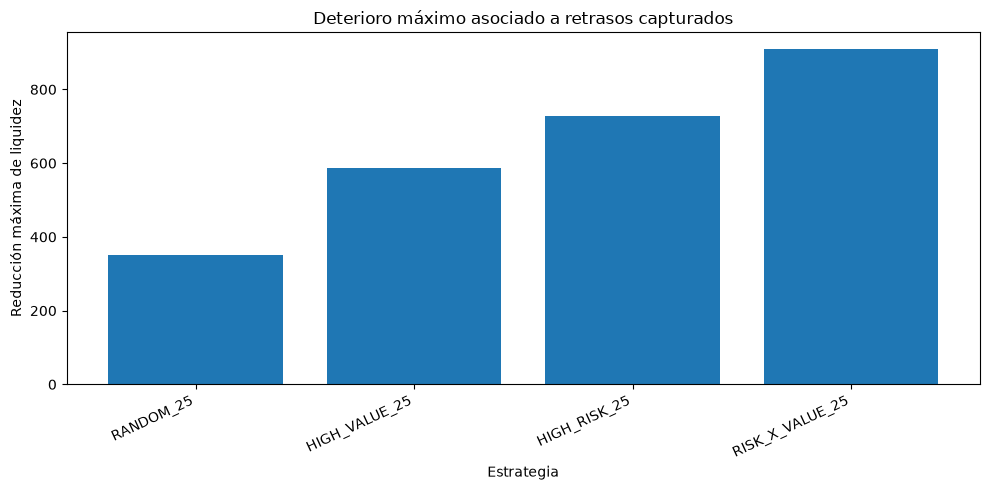

In [95]:
captured_stress_plot = (
    captured_late_treasury_comparison[
        ~captured_late_treasury_comparison[
            "strategy"
        ].eq(
            "BASE"
        )
    ]
)

fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.bar(
    captured_stress_plot[
        "strategy"
    ],
    captured_stress_plot[
        "maximum_liquidity_deterioration"
    ]
)

ax.set_title(
    "Deterioro máximo asociado a retrasos capturados"
)

ax.set_xlabel(
    "Estrategia"
)

ax.set_ylabel(
    "Reducción máxima de liquidez"
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.tight_layout()
plt.show()

### Trayectoria temporal del deterioro

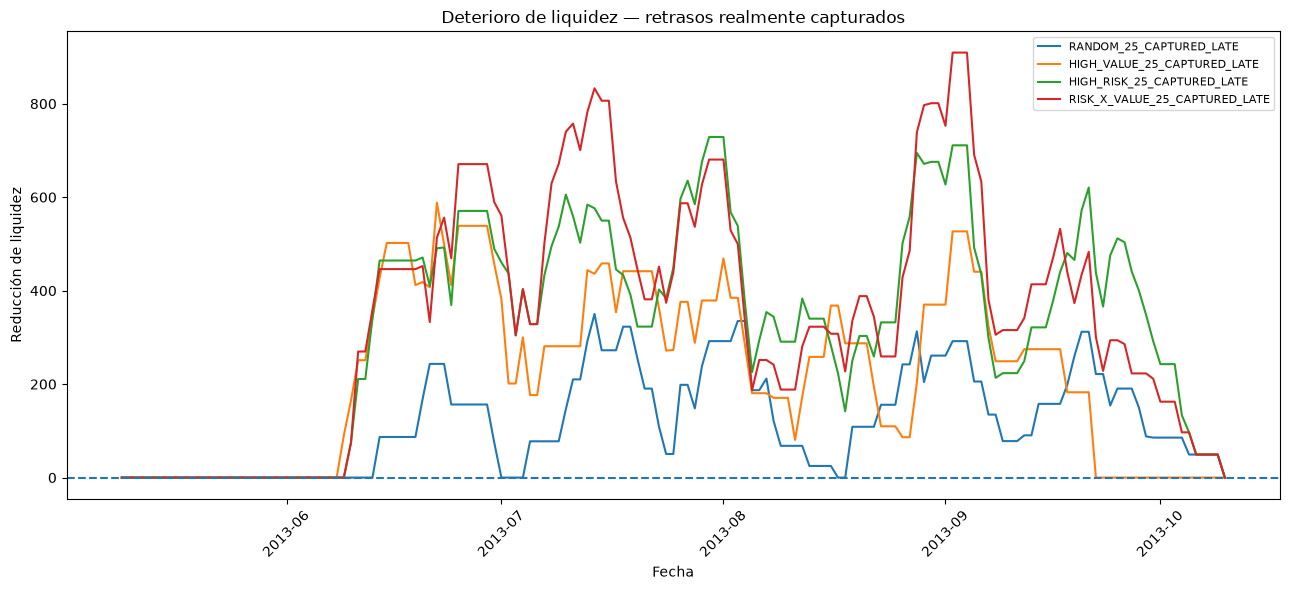

In [96]:
fig, ax = plt.subplots(
    figsize=(13, 6)
)

base_daily = (
    captured_late_daily[
        "BASE"
    ]
)

for (
    scenario_name,
    scenario_daily
) in captured_late_daily.items():

    if scenario_name == "BASE":
        continue

    deterioration = (
        base_daily[
            "closing_cash_balance"
        ].to_numpy()
        -
        scenario_daily[
            "closing_cash_balance"
        ].to_numpy()
    )

    ax.plot(
        scenario_daily.loc[
            captured_impact_mask,
            "date"
        ],

        deterioration[
            captured_impact_mask
        ],

        label=scenario_name,
    )

ax.axhline(
    0,
    linestyle="--"
)

ax.set_title(
    "Deterioro de liquidez — retrasos realmente capturados"
)

ax.set_xlabel(
    "Fecha"
)

ax.set_ylabel(
    "Reducción de liquidez"
)

ax.legend(
    fontsize=8
)

plt.xticks(
    rotation=45
)

plt.tight_layout()
plt.show()

### Interpretación del impacto condicionado

Este experimento es diferente del stress test del bloque anterior.

En el bloque 7 se aplicaron 10 días adicionales a **todas las facturas seleccionadas**.

En este bloque el shock se aplica únicamente a:

`facturas seleccionadas ∩ facturas realmente tardías`

Por tanto, la magnitud del escenario depende ahora también de la capacidad de cada estrategia para identificar eventos adversos.

Una estrategia puede seleccionar facturas de gran importe, pero si pocas de ellas terminan pagando tarde, una parte importante de su exposición no participa en este segundo escenario.

Por el contrario, una estrategia con elevada concentración de retrasos reales afectará a un número mayor de movimientos.

`RISK_X_VALUE_25` introduce además la dimensión del importe, por lo que puede concentrar menos eventos que `HIGH_RISK_25` y al mismo tiempo capturar una exposición monetaria tardía superior.

El objetivo del análisis no es determinar una estrategia universalmente mejor.

Se pretende distinguir tres propiedades:

- capacidad predictiva;
- exposición monetaria;
- consecuencia temporal sobre la liquidez.

## Conclusiones del impacto condicionado a retrasos capturados

El segundo experimento financiero limita el shock a las facturas priorizadas que realmente terminaron pagando tarde.

A diferencia del stress test anterior, las estrategias ya no afectan al mismo número de movimientos.

La magnitud del escenario depende ahora de la capacidad real de cada estrategia para identificar eventos adversos.

## Retrasos capturados

Las cuatro estrategias identifican:

- `RANDOM_25`: 29 retrasos;
- `HIGH_VALUE_25`: 38 retrasos;
- `HIGH_RISK_25`: 78 retrasos;
- `RISK_X_VALUE_25`: 74 retrasos.

Por tanto, la estrategia basada exclusivamente en riesgo predictivo concentra el mayor número de retrasos reales.

`HIGH_RISK_25` captura aproximadamente el 62,9 % de todos los retrasos del universo utilizando únicamente el 25,2 % de las facturas.

## Exposición monetaria tardía

El importe correspondiente a los retrasos capturados es:

- `RANDOM_25`: 1.849,22;
- `HIGH_VALUE_25`: 3.401,90;
- `HIGH_RISK_25`: 5.049,01;
- `RISK_X_VALUE_25`: 5.321,49.

Aunque `RISK_X_VALUE_25` captura cuatro facturas tardías menos que `HIGH_RISK_25`, concentra una exposición monetaria tardía superior.

Esto confirma el trade-off observado anteriormente:

`HIGH_RISK → mayor concentración de eventos`

`RISK × VALUE → mayor concentración de exposición adversa`

## Impacto sobre liquidez

El máximo deterioro diario respecto al escenario base es aproximadamente:

- `RANDOM_25`: 350,10;
- `HIGH_VALUE_25`: 588,17;
- `HIGH_RISK_25`: 728,83;
- `RISK_X_VALUE_25`: 909,41.

Cuando el shock se limita exclusivamente a los retrasos realmente capturados, las dos estrategias que utilizan información predictiva producen una presión de liquidez considerablemente superior a las referencias aleatoria y de importe.

`RISK_X_VALUE_25` genera el mayor deterioro máximo.

Este resultado se explica por la combinación de:

- una elevada concentración de retrasos reales;
- una mayor exposición monetaria asociada a dichos retrasos;
- el momento concreto en que los cobros afectados deberían producirse.

## Comparación con el stress de todo el portfolio seleccionado

En el experimento anterior se retrasaron las 96 facturas seleccionadas por cada estrategia, independientemente de su comportamiento real.

Al restringir el shock únicamente a facturas realmente tardías, el porcentaje del deterioro máximo que permanece es aproximadamente:

- `RANDOM_25`: 41,6 %;
- `HIGH_VALUE_25`: 50,0 %;
- `HIGH_RISK_25`: 90,2 %;
- `RISK_X_VALUE_25`: 83,9 %.

Esto muestra una diferencia relevante.

En las estrategias aleatoria y de mayor importe, una parte importante del stress potencial procedía de facturas que finalmente pagaron de forma puntual.

En cambio, en las estrategias basadas en riesgo predictivo, la mayor parte de la presión financiera potencial se concentra en operaciones que realmente terminaron pagando tarde.

## Interpretación del valor predictivo

Los resultados muestran que el modelo aporta información útil más allá del importe de la factura.

`HIGH_RISK_25` es especialmente eficaz para concentrar eventos de retraso.

Por su parte, `RISK_X_VALUE_25` combina esa señal predictiva con la exposición monetaria y produce el mayor impacto de liquidez entre los retrasos realmente capturados.

Por tanto, dentro de este experimento pueden distinguirse dos posibles objetivos operativos:

### Gestión de cobros

Si el objetivo principal es identificar el mayor número posible de facturas con probabilidad elevada de retraso, `HIGH_RISK_25` proporciona la señal más directa.

### Gestión de tesorería

Si el objetivo es priorizar operaciones donde coinciden riesgo de retraso y exposición monetaria relevante, `RISK_X_VALUE_25` concentra un impacto financiero superior.

Estas conclusiones se refieren exclusivamente al universo `VALIDATION_OOS` y al shock contrafactual de 10 días utilizado en el experimento.

No deben interpretarse como evidencia de que una estrategia sea universalmente superior en otras carteras, períodos o condiciones financieras.

## Limitación

El análisis utiliza el comportamiento real `late_payment` únicamente después de haber definido las estrategias.

Por tanto, esta información no participa en la priorización y no existe data leakage en el ranking.

Sin embargo, el escenario sigue siendo retrospectivo y contrafactual.

El shock de 10 días representa un deterioro adicional sobre la fecha real de cobro y no una predicción directa del número futuro de días de retraso.

El resultado debe interpretarse como una evaluación del valor de priorización del modelo y no como una previsión completa de tesorería ex-ante.

## 9. Benchmark Monte Carlo de las estrategias predictivas

Las comparaciones anteriores utilizan una única selección aleatoria reproducible como referencia.

Sin embargo, distintas muestras aleatorias de 96 facturas pueden producir:

- diferente exposición monetaria;
- distinto número de retrasos reales;
- diferente concentración temporal;
- distinto impacto sobre la tesorería.

Para evaluar la robustez de los resultados se construirá un benchmark Monte Carlo.

## Diseño

En cada repetición:

1. se seleccionarán aleatoriamente 96 facturas del universo `VALIDATION_OOS`;
2. la selección se realizará sin utilizar `late_payment`;
3. se calculará su exposición monetaria;
4. se medirá cuántos retrasos reales contiene;
5. se reproducirán los dos experimentos financieros anteriores.

### Stress del portfolio

Se aplicarán:

`+10 días`

a las 96 facturas seleccionadas.

### Impacto condicionado

Se aplicarán:

`+10 días`

únicamente a:

`seleccionadas ∩ late_payment = 1`

Por tanto, el Monte Carlo permitirá comparar las estrategias deterministas contra la distribución de resultados que podría obtenerse mediante selección aleatoria.

## Interpretación

El objetivo no es estimar una probabilidad universal de superioridad.

Los percentiles obtenidos describen únicamente este universo de 381 facturas y este escenario contrafactual.

Sirven como benchmark empírico para determinar si los rankings basados en riesgo y exposición concentran resultados claramente diferentes de los obtenidos al azar.

### Configuracion de Monte Carlo

In [97]:
OOS_MONTE_CARLO_REPEATS = 500

oos_monte_carlo_rng = np.random.default_rng(
    int(
        simulation_metadata[
            "random_seed"
        ]
    )
    + 6000
)

primary_movement_ids = (
    primary_risk_treasury_universe[
        "movement_id"
    ]
    .to_numpy()
)

print(
    "Repeticiones:",
    OOS_MONTE_CARLO_REPEATS
)

print(
    "Facturas seleccionadas por repetición:",
    PRIORITIZATION_COUNT
)

Repeticiones: 500
Facturas seleccionadas por repetición: 96


### Preparar referencias BASE

In [98]:
monte_carlo_base_daily = (
    treasury_strategy_daily[
        "BASE"
    ]
)

monte_carlo_base_balance = (
    monte_carlo_base_daily[
        "closing_cash_balance"
    ]
    .to_numpy()
)

monte_carlo_impact_mask = (
    monte_carlo_base_daily[
        "date"
    ]
    .between(
        impact_window_start,
        impact_window_end,
    )
    .to_numpy()
)

### Ejecutar Monte Carlo

In [99]:
oos_monte_carlo_rows = []

for iteration in range(
    OOS_MONTE_CARLO_REPEATS
):

    # ----------------------------------
    # Selección aleatoria
    # ----------------------------------

    random_ids = set(
        oos_monte_carlo_rng.choice(
            primary_movement_ids,
            size=PRIORITIZATION_COUNT,
            replace=False,
        )
    )

    random_selected_df = (
        primary_risk_treasury_universe[
            primary_risk_treasury_universe[
                "movement_id"
            ].isin(
                random_ids
            )
        ]
    )

    selected_amount = (
        random_selected_df[
            "amount"
        ].sum()
    )

    # ----------------------------------
    # Retrasos reales capturados
    # ----------------------------------

    random_captured_late_ids = (
        random_ids
        &
        actual_late_ids
    )

    random_captured_late_df = (
        primary_risk_treasury_universe[
            primary_risk_treasury_universe[
                "movement_id"
            ].isin(
                random_captured_late_ids
            )
        ]
    )

    captured_late_count = (
        len(
            random_captured_late_df
        )
    )

    captured_late_amount = (
        random_captured_late_df[
            "amount"
        ].sum()
    )

    # ==================================
    # A. STRESS DEL PORTFOLIO
    # ==================================

    portfolio_movements = (
        create_prioritization_stress_scenario(
            movements=cash_movements,
            selected_movement_ids=random_ids,
            delay_days=SELECTIVE_STRESS_DAYS,
        )
    )

    portfolio_daily = (
        build_daily_cashflow(
            movements=portfolio_movements,
            initial_cash=initial_cash_balance,
            start_date=simulation_start_date,
            end_date=simulation_end_date,
        )
    )

    portfolio_deterioration = (
        monte_carlo_base_balance
        -
        portfolio_daily[
            "closing_cash_balance"
        ].to_numpy()
    )

    portfolio_impact_deterioration = (
        portfolio_deterioration[
            monte_carlo_impact_mask
        ]
    )

    portfolio_max_deterioration = (
        portfolio_impact_deterioration.max()
    )

    portfolio_average_deterioration = (
        portfolio_impact_deterioration.mean()
    )

    portfolio_amount_days = (
        portfolio_impact_deterioration.sum()
    )

    # ==================================
    # B. RETRASOS REALMENTE CAPTURADOS
    # ==================================

    captured_movements = (
        create_prioritization_stress_scenario(
            movements=cash_movements,
            selected_movement_ids=(
                random_captured_late_ids
            ),
            delay_days=SELECTIVE_STRESS_DAYS,
        )
    )

    captured_daily = (
        build_daily_cashflow(
            movements=captured_movements,
            initial_cash=initial_cash_balance,
            start_date=simulation_start_date,
            end_date=simulation_end_date,
        )
    )

    captured_deterioration = (
        monte_carlo_base_balance
        -
        captured_daily[
            "closing_cash_balance"
        ].to_numpy()
    )

    captured_impact_deterioration = (
        captured_deterioration[
            monte_carlo_impact_mask
        ]
    )

    captured_max_deterioration = (
        captured_impact_deterioration.max()
    )

    captured_average_deterioration = (
        captured_impact_deterioration.mean()
    )

    captured_amount_days = (
        captured_impact_deterioration.sum()
    )

    # ----------------------------------
    # Guardar resultados
    # ----------------------------------

    oos_monte_carlo_rows.append({
        "iteration": (
            iteration + 1
        ),

        "selected_amount": (
            selected_amount
        ),

        "selected_amount_pct": (
            selected_amount
            /
            primary_risk_treasury_universe[
                "amount"
            ].sum()
        ),

        "captured_late_count": (
            captured_late_count
        ),

        "captured_late_amount": (
            captured_late_amount
        ),

        "captured_late_amount_pct": (
            captured_late_amount
            /
            actual_late_receipts[
                "amount"
            ].sum()
        ),

        "portfolio_max_deterioration": (
            portfolio_max_deterioration
        ),

        "portfolio_average_deterioration": (
            portfolio_average_deterioration
        ),

        "portfolio_amount_days": (
            portfolio_amount_days
        ),

        "captured_max_deterioration": (
            captured_max_deterioration
        ),

        "captured_average_deterioration": (
            captured_average_deterioration
        ),

        "captured_amount_days": (
            captured_amount_days
        ),
    })

### Creat dataframe Monte Carlo

In [100]:
oos_monte_carlo = pd.DataFrame(
    oos_monte_carlo_rows
)

assert (
    len(
        oos_monte_carlo
    )
    ==
    OOS_MONTE_CARLO_REPEATS
)

oos_monte_carlo.head()

,iteration,selected_amount,selected_amount_pct,captured_late_count,captured_late_amount,captured_late_amount_pct,portfolio_max_deterioration,portfolio_average_deterioration,portfolio_amount_days,captured_max_deterioration,captured_average_deterioration,captured_amount_days
0,1,5778.69,0.252078,30,1748.99,0.223020,973.85,372.818710,57786.9,346.26,112.838065,17489.9
1,2,5649.28,0.246433,31,1758.82,0.224273,892.36,364.469677,56492.8,380.64,113.472258,17588.2
2,3,5873.65,0.256220,29,1859.48,0.237109,1056.17,378.945161,58736.5,471.52,119.966452,18594.8
3,4,5453.48,0.237892,28,1722.81,0.219682,778.89,351.837419,54534.8,432.34,111.149032,17228.1
4,5,5813.37,0.253591,26,1696.58,0.216337,894.64,375.056129,58133.7,400.62,109.456774,16965.8


### Validar exposicion acumulada

In [101]:
assert np.allclose(
    oos_monte_carlo[
        "portfolio_amount_days"
    ],
    oos_monte_carlo[
        "selected_amount"
    ]
    *
    SELECTIVE_STRESS_DAYS
)

assert np.allclose(
    oos_monte_carlo[
        "captured_amount_days"
    ],
    oos_monte_carlo[
        "captured_late_amount"
    ]
    *
    SELECTIVE_STRESS_DAYS
)

print(
    "✓ Monte Carlo conciliado con "
    "importe × días de retraso."
)

✓ Monte Carlo conciliado con importe × días de retraso.


#### Resumen estadistico

In [102]:
oos_monte_carlo_summary = (
    oos_monte_carlo[
        [
            "selected_amount_pct",
            "captured_late_count",
            "captured_late_amount",
            "captured_late_amount_pct",
            "portfolio_max_deterioration",
            "portfolio_average_deterioration",
            "captured_max_deterioration",
            "captured_average_deterioration",
        ]
    ]
    .describe(
        percentiles=[
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
        ]
    )
    .T
)

oos_monte_carlo_summary

,count,mean,std,min,5%,25%,50%,75%,95%,max
selected_amount_pct,500.0,0.252815,0.007276,0.232884,0.241721,0.247560,0.252366,0.257827,0.264451,0.275420
captured_late_count,500.0,31.354000,3.850498,21.000000,25.000000,29.000000,31.000000,34.000000,38.000000,45.000000
captured_late_amount,500.0,1990.644820,268.853444,1321.720000,1560.265500,1820.590000,1976.865000,2167.822500,2440.836500,2819.500000
captured_late_amount_pct,500.0,0.253834,0.034282,0.168537,0.198955,0.232150,0.252077,0.276427,0.311240,0.359525
portfolio_max_deterioration,500.0,899.582280,101.141427,702.190000,753.148000,828.455000,891.040000,957.467500,1086.766000,1226.330000
portfolio_average_deterioration,500.0,373.908476,10.761594,344.431613,357.500548,366.136935,373.245161,381.321129,391.117613,407.340645
captured_max_deterioration,500.0,428.171120,74.933888,257.430000,318.917000,376.330000,419.750000,473.550000,567.666000,729.130000
captured_average_deterioration,500.0,128.428698,17.345383,85.272258,100.662290,117.457419,127.539677,139.859516,157.473323,181.903226


### Construir referencia de estrategias deterministas

In [103]:
deterministic_benchmark = (
    prioritization_summary[
        prioritization_summary[
            "strategy"
        ].isin(
            [
                "HIGH_VALUE_25",
                "HIGH_RISK_25",
                "RISK_X_VALUE_25",
            ]
        )
    ]
    [
        [
            "strategy",
            "selected_amount",
            "selected_amount_pct",
            "observed_late_count",
            "selected_late_amount",
            "late_amount_capture_pct",
        ]
    ]
    .copy()
)

deterministic_benchmark = (
    deterministic_benchmark
    .merge(
        treasury_strategy_summary[
            [
                "strategy",
                "maximum_liquidity_deterioration",
                "average_liquidity_deterioration",
            ]
        ]
        .rename(
            columns={
                "maximum_liquidity_deterioration":
                    "portfolio_max_deterioration",

                "average_liquidity_deterioration":
                    "portfolio_average_deterioration",
            }
        ),
        on="strategy",
        validate="one_to_one",
    )
)

deterministic_benchmark = (
    deterministic_benchmark
    .merge(
        captured_late_treasury_summary[
            [
                "strategy",
                "maximum_liquidity_deterioration",
                "average_liquidity_deterioration",
            ]
        ]
        .rename(
            columns={
                "maximum_liquidity_deterioration":
                    "captured_max_deterioration",

                "average_liquidity_deterioration":
                    "captured_average_deterioration",
            }
        ),
        on="strategy",
        validate="one_to_one",
    )
)

deterministic_benchmark

,strategy,selected_amount,selected_amount_pct,observed_late_count,selected_late_amount,late_amount_capture_pct,portfolio_max_deterioration,portfolio_average_deterioration,captured_max_deterioration,captured_average_deterioration
0,HIGH_VALUE_25,8171.29,0.356448,38,3401.90,0.433789,1175.50,527.180000,588.17,219.477419
1,HIGH_RISK_25,6090.87,0.265696,78,5049.01,0.643818,807.71,392.959355,728.83,325.742581
2,RISK_X_VALUE_25,6937.57,0.302631,74,5321.49,0.678562,1083.31,447.585161,909.41,343.321935


### Funcion percentil frente a aleatorio

In [104]:
def empirical_percentile(
    random_values,
    strategy_value,
):
    return (
        random_values
        <= strategy_value
    ).mean()

### Calcular percentiles empiricos

In [105]:
strategy_percentile_rows = []

for _, row in (
    deterministic_benchmark
    .iterrows()
):

    strategy_percentile_rows.append({
        "strategy": (
            row[
                "strategy"
            ]
        ),

        "selected_amount_percentile": (
            empirical_percentile(
                oos_monte_carlo[
                    "selected_amount"
                ],
                row[
                    "selected_amount"
                ],
            )
        ),

        "captured_late_count_percentile": (
            empirical_percentile(
                oos_monte_carlo[
                    "captured_late_count"
                ],
                row[
                    "observed_late_count"
                ],
            )
        ),

        "captured_late_amount_percentile": (
            empirical_percentile(
                oos_monte_carlo[
                    "captured_late_amount"
                ],
                row[
                    "selected_late_amount"
                ],
            )
        ),

        "portfolio_max_deterioration_percentile": (
            empirical_percentile(
                oos_monte_carlo[
                    "portfolio_max_deterioration"
                ],
                row[
                    "portfolio_max_deterioration"
                ],
            )
        ),

        "captured_max_deterioration_percentile": (
            empirical_percentile(
                oos_monte_carlo[
                    "captured_max_deterioration"
                ],
                row[
                    "captured_max_deterioration"
                ],
            )
        ),
    })

strategy_vs_random_percentiles = (
    pd.DataFrame(
        strategy_percentile_rows
    )
)

strategy_vs_random_percentiles

,strategy,selected_amount_percentile,captured_late_count_percentile,captured_late_amount_percentile,portfolio_max_deterioration_percentile,captured_max_deterioration_percentile
0,HIGH_VALUE_25,1.000,0.964,1.0,0.986,0.970
1,HIGH_RISK_25,0.958,1.000,1.0,0.188,0.998
2,RISK_X_VALUE_25,1.000,1.000,1.0,0.946,1.000


### Añadir valores absolutos

In [106]:
strategy_vs_random = (
    deterministic_benchmark
    .merge(
        strategy_vs_random_percentiles,
        on="strategy",
        validate="one_to_one",
    )
)

strategy_vs_random

,strategy,selected_amount,selected_amount_pct,observed_late_count,selected_late_amount,late_amount_capture_pct,portfolio_max_deterioration,portfolio_average_deterioration,captured_max_deterioration,captured_average_deterioration,selected_amount_percentile,captured_late_count_percentile,captured_late_amount_percentile,portfolio_max_deterioration_percentile,captured_max_deterioration_percentile
0,HIGH_VALUE_25,8171.29,0.356448,38,3401.90,0.433789,1175.50,527.180000,588.17,219.477419,1.000,0.964,1.0,0.986,0.970
1,HIGH_RISK_25,6090.87,0.265696,78,5049.01,0.643818,807.71,392.959355,728.83,325.742581,0.958,1.000,1.0,0.188,0.998
2,RISK_X_VALUE_25,6937.57,0.302631,74,5321.49,0.678562,1083.31,447.585161,909.41,343.321935,1.000,1.000,1.0,0.946,1.000


### Mediana aleatoria de referencia

In [107]:
random_median_reference = pd.Series({
    "selected_amount": (
        oos_monte_carlo[
            "selected_amount"
        ].median()
    ),

    "captured_late_count": (
        oos_monte_carlo[
            "captured_late_count"
        ].median()
    ),

    "captured_late_amount": (
        oos_monte_carlo[
            "captured_late_amount"
        ].median()
    ),

    "portfolio_max_deterioration": (
        oos_monte_carlo[
            "portfolio_max_deterioration"
        ].median()
    ),

    "captured_max_deterioration": (
        oos_monte_carlo[
            "captured_max_deterioration"
        ].median()
    ),
})

random_median_reference

selected_amount                5785.300
captured_late_count              31.000
captured_late_amount           1976.865
portfolio_max_deterioration     891.040
captured_max_deterioration      419.750
dtype: float64

### Visualizar retrasos capturados vs distribucion aleatoria

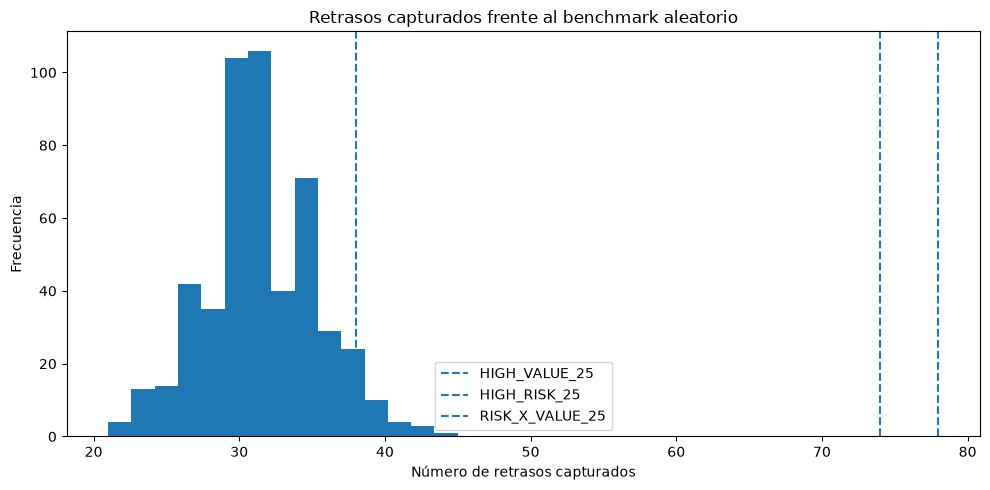

In [108]:
fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.hist(
    oos_monte_carlo[
        "captured_late_count"
    ],
    bins=15,
)

for _, row in (
    deterministic_benchmark.iterrows()
):
    ax.axvline(
        row[
            "observed_late_count"
        ],
        linestyle="--",
        label=row[
            "strategy"
        ],
    )

ax.set_title(
    "Retrasos capturados frente al benchmark aleatorio"
)

ax.set_xlabel(
    "Número de retrasos capturados"
)

ax.set_ylabel(
    "Frecuencia"
)

ax.legend()

plt.tight_layout()
plt.show()

### Visualizar importe tardio capturado

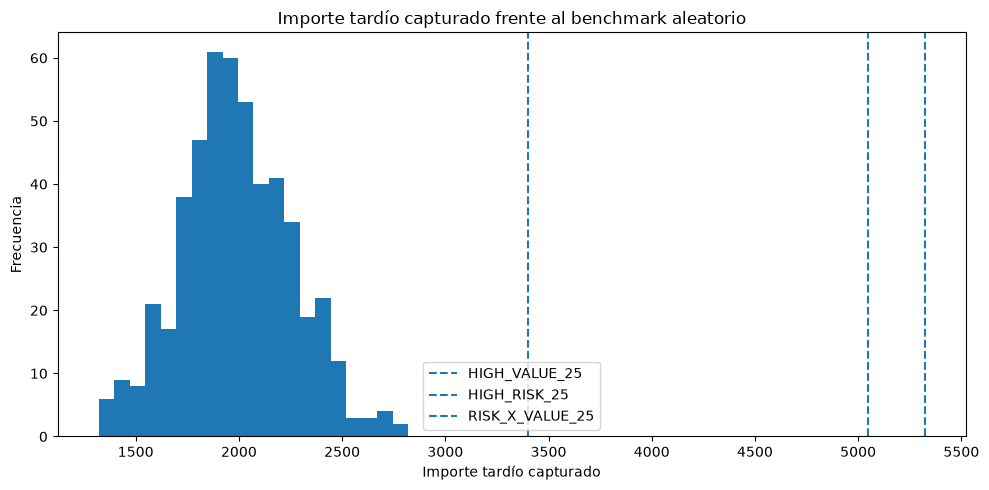

In [109]:
fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.hist(
    oos_monte_carlo[
        "captured_late_amount"
    ],
    bins=20,
)

for _, row in (
    deterministic_benchmark.iterrows()
):
    ax.axvline(
        row[
            "selected_late_amount"
        ],
        linestyle="--",
        label=row[
            "strategy"
        ],
    )

ax.set_title(
    "Importe tardío capturado frente al benchmark aleatorio"
)

ax.set_xlabel(
    "Importe tardío capturado"
)

ax.set_ylabel(
    "Frecuencia"
)

ax.legend()

plt.tight_layout()
plt.show()

### Visualizar deterioro condicionado

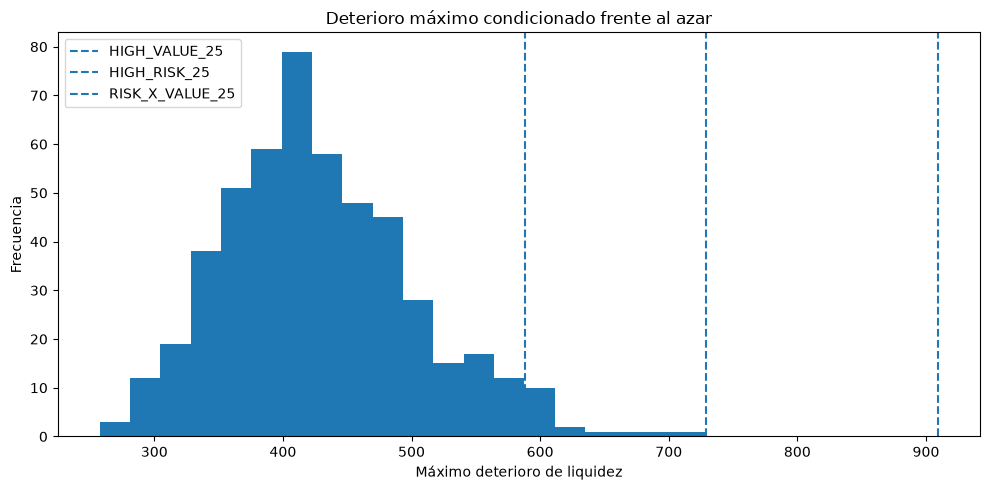

In [110]:
fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.hist(
    oos_monte_carlo[
        "captured_max_deterioration"
    ],
    bins=20,
)

for _, row in (
    deterministic_benchmark.iterrows()
):
    ax.axvline(
        row[
            "captured_max_deterioration"
        ],
        linestyle="--",
        label=row[
            "strategy"
        ],
    )

ax.set_title(
    "Deterioro máximo condicionado frente al azar"
)

ax.set_xlabel(
    "Máximo deterioro de liquidez"
)

ax.set_ylabel(
    "Frecuencia"
)

ax.legend()

plt.tight_layout()
plt.show()

### Interpretación del benchmark Monte Carlo

El benchmark Monte Carlo permite sustituir la comparación contra una única muestra aleatoria por una distribución empírica de resultados.

Para cada estrategia determinista se calculará el porcentaje de selecciones aleatorias con un resultado inferior o igual.

Por ejemplo:

`captured_late_count_percentile = 0,99`

significa que la estrategia captura al menos tantos retrasos como aproximadamente el 99 % de las selecciones aleatorias simuladas.

Un percentil elevado no implica que la estrategia sea universalmente superior.

El resultado está condicionado por:

- el universo `VALIDATION_OOS`;
- la selección del 25,2 % de las facturas;
- el shock contrafactual de 10 días;
- la estructura concreta de cobros y pagos del escenario.

El análisis sirve como comprobación de robustez interna del valor de priorización.

Un percentil empírico igual a `1,000` significa que ninguna de las 500 selecciones aleatorias simuladas obtuvo un valor superior a la estrategia analizada.

No debe interpretarse como una probabilidad teórica del 100 % ni como una garantía de superioridad en otras muestras.

El benchmark describe únicamente la distribución aleatoria observada dentro de este experimento.

## Conclusiones del benchmark Monte Carlo

El benchmark Monte Carlo amplía la comparación frente al azar mediante 500 selecciones independientes de 96 facturas sobre el mismo universo `VALIDATION_OOS`.

Cada selección aleatoria utiliza:

- el mismo número de facturas;
- el mismo shock de 10 días;
- los mismos movimientos de salida;
- el mismo saldo inicial;
- el mismo horizonte de tesorería.

Por tanto, la distribución obtenida proporciona una referencia empírica para interpretar las estrategias deterministas.

## Referencia aleatoria

La mediana de las 500 simulaciones aleatorias presenta aproximadamente:

- importe seleccionado: `5.785,30`;
- retrasos reales capturados: `31`;
- importe tardío capturado: `1.976,87`;
- deterioro máximo del portfolio: `891,04`;
- deterioro máximo condicionado a retrasos capturados: `419,75`.

Estos valores representan el comportamiento típico obtenido mediante una selección sin información predictiva ni financiera específica.

## HIGH VALUE 25

La estrategia basada en importe captura:

- 38 retrasos reales;
- 3.401,90 unidades monetarias de importe tardío;
- deterioro máximo del portfolio de 1.175,50;
- deterioro condicionado de 588,17.

Frente a las 500 selecciones aleatorias, se sitúa aproximadamente en:

- percentil 96,4 % en número de retrasos capturados;
- percentil 100 % en importe tardío capturado;
- percentil 98,6 % en deterioro máximo del portfolio;
- percentil 97,0 % en deterioro condicionado.

La estrategia concentra una exposición monetaria elevada, aunque no está diseñada específicamente para predecir retrasos.

## HIGH RISK 25

La estrategia basada únicamente en riesgo predictivo captura:

- 78 retrasos reales;
- 5.049,01 unidades monetarias de importe tardío;
- deterioro máximo del portfolio de 807,71;
- deterioro condicionado de 728,83.

El número de retrasos y el importe tardío capturados superan los resultados observados en las 500 selecciones aleatorias.

Sin embargo, cuando se retrasa todo el portfolio seleccionado, su deterioro máximo se sitúa únicamente alrededor del percentil 18,8 % de la distribución aleatoria.

Este resultado es coherente con el objetivo de la estrategia.

`HIGH_RISK_25` prioriza probabilidad de retraso y no exposición monetaria total.

Cuando el análisis se limita a las facturas seleccionadas que realmente resultaron tardías, el deterioro alcanza aproximadamente el percentil 99,8 %.

Por tanto, la señal predictiva se concentra especialmente en los eventos adversos que el modelo pretende identificar.

## RISK × VALUE 25

La estrategia combinada captura:

- 74 retrasos reales;
- 5.321,49 unidades monetarias de importe tardío;
- deterioro máximo del portfolio de 1.083,31;
- deterioro condicionado de 909,41.

Los retrasos capturados y el importe tardío superan los resultados de las 500 selecciones aleatorias.

El stress completo del portfolio se sitúa aproximadamente en el percentil 94,6 %.

Cuando el shock se restringe a retrasos realmente capturados, el deterioro de 909,41 unidades monetarias supera incluso el máximo observado entre las 500 selecciones aleatorias, cuyo valor máximo es aproximadamente 729,13.

Esto indica que la combinación entre riesgo predictivo y exposición monetaria concentra una parte especialmente relevante de la presión financiera asociada a eventos adversos.

## Comparación entre objetivos

Los resultados muestran que no existe una única dimensión de priorización.

`HIGH_VALUE_25`

prioriza principalmente:

`exposición monetaria`

`HIGH_RISK_25`

prioriza principalmente:

`probabilidad de retraso`

`RISK_X_VALUE_25`

combina:

`probabilidad de retraso × exposición monetaria`

Dentro de este experimento, `HIGH_RISK_25` es la estrategia más eficaz para concentrar el número de retrasos reales.

Por su parte, `RISK_X_VALUE_25` concentra el mayor importe tardío y genera el mayor deterioro de liquidez cuando el shock se limita a los eventos adversos realmente capturados.

## Interpretación del valor del modelo

El benchmark Monte Carlo aporta evidencia de que los resultados de las estrategias predictivas no dependen únicamente de una selección aleatoria favorable.

La señal del modelo permite concentrar un número de retrasos considerablemente superior al comportamiento típico observado al azar.

Al incorporar además el importe de la factura, esa capacidad predictiva puede traducirse en una concentración superior de exposición financiera.

Por tanto, los resultados apoyan el uso del modelo como herramienta de priorización para:

- seguimiento de cuentas a cobrar;
- gestión preventiva de cobros;
- identificación de exposición financiera;
- construcción de escenarios de tesorería.

## Limitaciones

Los percentiles obtenidos son empíricos y se calculan únicamente sobre las 500 muestras aleatorias simuladas.

Un percentil igual a `1,000` significa que ninguna de las selecciones aleatorias observadas obtuvo un resultado superior.

No representa una probabilidad teórica del 100 % ni garantiza que el mismo resultado se reproduzca en otros períodos o carteras.

Además, el análisis continúa siendo contrafactual.

El shock de 10 días se aplica sobre fechas reales de cobro ya observadas y no constituye una predicción directa del número futuro de días hasta liquidación.

Los resultados deben interpretarse como evidencia interna sobre el valor de priorización del modelo dentro del entorno simulado del proyecto.

## 10. Síntesis final de la integración riesgo–tesorería

El objetivo final del notebook es consolidar los resultados obtenidos durante la integración entre:

- modelo predictivo de retraso;
- priorización de cuentas a cobrar;
- exposición monetaria;
- simulación diaria de tesorería.

No se introducirán nuevos escenarios en este bloque.

Se resumirán las principales métricas obtenidas, se almacenarán los datasets derivados relevantes y se documentarán las limitaciones y conclusiones finales del sistema.

### Construir tabla ejecutiva final

In [111]:
final_strategy_summary = (
    prioritization_summary
    .merge(
        treasury_strategy_summary[
            [
                "strategy",
                "maximum_liquidity_deterioration",
                "average_liquidity_deterioration",
            ]
        ]
        .rename(
            columns={
                "maximum_liquidity_deterioration":
                    "portfolio_max_deterioration",

                "average_liquidity_deterioration":
                    "portfolio_average_deterioration",
            }
        ),
        on="strategy",
        how="left",
        validate="one_to_one",
    )
    .merge(
        captured_late_treasury_summary[
            [
                "strategy",
                "affected_late_count",
                "affected_late_amount",
                "maximum_liquidity_deterioration",
                "average_liquidity_deterioration",
            ]
        ]
        .rename(
            columns={
                "maximum_liquidity_deterioration":
                    "captured_max_deterioration",

                "average_liquidity_deterioration":
                    "captured_average_deterioration",
            }
        ),
        on="strategy",
        how="left",
        validate="one_to_one",
    )
    .merge(
        strategy_vs_random_percentiles,
        on="strategy",
        how="left",
        validate="one_to_one",
    )
)

final_strategy_summary[
    "captured_to_portfolio_deterioration"
] = (
    final_strategy_summary[
        "captured_max_deterioration"
    ]
    /
    final_strategy_summary[
        "portfolio_max_deterioration"
    ]
)

display(final_strategy_summary)

expected_percentile_columns = [
    "captured_late_count_percentile",
    "captured_late_amount_percentile",
    "captured_max_deterioration_percentile",
]

missing_percentile_columns = [
    column
    for column in expected_percentile_columns
    if column not in final_strategy_summary.columns
]

assert not missing_percentile_columns, (
    "Faltan columnas Monte Carlo: "
    f"{missing_percentile_columns}"
)

print(
    "✓ Percentiles Monte Carlo incorporados "
    "a la tabla final."
)

,strategy,selected_count,selected_count_pct,selected_amount,selected_amount_pct,average_selected_amount,mean_predicted_risk,median_predicted_risk,observed_late_count,observed_late_rate,...,affected_late_count,affected_late_amount,captured_max_deterioration,captured_average_deterioration,selected_amount_percentile,captured_late_count_percentile,captured_late_amount_percentile,portfolio_max_deterioration_percentile,captured_max_deterioration_percentile,captured_to_portfolio_deterioration
0,RANDOM_25,96,0.251969,5830.89,0.254355,60.738437,0.412957,0.254916,29,0.302083,...,29,1849.22,350.10,119.304516,NaN,NaN,NaN,NaN,NaN,0.416092
1,HIGH_VALUE_25,96,0.251969,8171.29,0.356448,85.117604,0.468307,0.419621,38,0.395833,...,38,3401.90,588.17,219.477419,1.000,0.964,1.0,0.986,0.970,0.500357
2,HIGH_RISK_25,96,0.251969,6090.87,0.265696,63.446563,0.884568,0.903661,78,0.812500,...,78,5049.01,728.83,325.742581,0.958,1.000,1.0,0.188,0.998,0.902341
3,RISK_X_VALUE_25,96,0.251969,6937.57,0.302631,72.266354,0.841050,0.887268,74,0.770833,...,74,5321.49,909.41,343.321935,1.000,1.000,1.0,0.946,1.000,0.839473


✓ Percentiles Monte Carlo incorporados a la tabla final.


In [112]:
expected_strategies = {
    "RANDOM_25",
    "HIGH_VALUE_25",
    "HIGH_RISK_25",
    "RISK_X_VALUE_25",
}

assert (
    set(
        final_strategy_summary[
            "strategy"
        ]
    )
    ==
    expected_strategies
)

assert final_strategy_summary[
    "strategy"
].is_unique

assert (
    len(
        final_strategy_summary
    )
    == 4
)

assert (
    final_strategy_summary[
        "selected_count"
    ]
    ==
    PRIORITIZATION_COUNT
).all()

assert final_strategy_summary[
    "observed_late_rate"
].between(
    0,
    1
).all()

assert final_strategy_summary[
    "late_invoice_capture_pct"
].between(
    0,
    1
).all()

assert final_strategy_summary[
    "late_amount_capture_pct"
].between(
    0,
    1
).all()

print(
    "✓ Tabla ejecutiva final validada."
)

✓ Tabla ejecutiva final validada.


### Vista ejecutiva

In [113]:
executive_strategy_summary = (
    final_strategy_summary[
        [
            "strategy",
            "selected_count",
            "selected_amount_pct",
            "observed_late_rate",
            "late_rate_lift",
            "late_invoice_capture_pct",
            "late_amount_capture_pct",
            "portfolio_max_deterioration",
            "captured_max_deterioration",
            "captured_to_portfolio_deterioration",
            "captured_late_count_percentile",
            "captured_late_amount_percentile",
            "captured_max_deterioration_percentile",
        ]
    ]
    .copy()
)

executive_strategy_summary

,strategy,selected_count,selected_amount_pct,observed_late_rate,late_rate_lift,late_invoice_capture_pct,late_amount_capture_pct,portfolio_max_deterioration,captured_max_deterioration,captured_to_portfolio_deterioration,captured_late_count_percentile,captured_late_amount_percentile,captured_max_deterioration_percentile
0,RANDOM_25,96,0.254355,0.302083,0.928175,0.233871,0.235801,841.40,350.10,0.416092,NaN,NaN,NaN
1,HIGH_VALUE_25,96,0.356448,0.395833,1.216230,0.306452,0.433789,1175.50,588.17,0.500357,0.964,1.0,0.970
2,HIGH_RISK_25,96,0.265696,0.812500,2.496472,0.629032,0.643818,807.71,728.83,0.902341,1.000,1.0,0.998
3,RISK_X_VALUE_25,96,0.302631,0.770833,2.368448,0.596774,0.678562,1083.31,909.41,0.839473,1.000,1.0,1.000


### Lectura ejecutiva de las estrategias

La tabla final reúne tres dimensiones distintas.

### Capacidad predictiva

Se representa mediante:

- `observed_late_rate`;
- `late_rate_lift`;
- `late_invoice_capture_pct`.

Estas métricas indican hasta qué punto la estrategia concentra facturas que realmente terminan pagando tarde.

### Exposición financiera

Se representa principalmente mediante:

- `selected_amount_pct`;
- `late_amount_capture_pct`.

Estas métricas indican cuánto volumen monetario y cuánto importe realmente tardío concentra cada estrategia.

### Impacto sobre tesorería

Se representa mediante:

- `portfolio_max_deterioration`;
- `captured_max_deterioration`.

La primera métrica corresponde al stress aplicado a todo el portfolio seleccionado.

La segunda restringe el shock a las facturas seleccionadas que realmente terminaron pagando tarde.

Esta segunda aproximación permite relacionar de forma más directa la capacidad predictiva con la exposición financiera adversa efectivamente identificada.

### Tabla orientada a objetivos

In [114]:
objective_summary = pd.DataFrame([
    {
        "objective": (
            "Concentrar retrasos reales"
        ),

        "strategy": (
            "HIGH_RISK_25"
        ),

        "key_result": (
            "78 retrasos capturados "
            "(62,9 % del total)"
        ),
    },

    {
        "objective": (
            "Concentrar importe tardío"
        ),

        "strategy": (
            "RISK_X_VALUE_25"
        ),

        "key_result": (
            "67,9 % del importe tardío capturado"
        ),
    },

    {
        "objective": (
            "Concentrar exposición total"
        ),

        "strategy": (
            "HIGH_VALUE_25"
        ),

        "key_result": (
            "35,6 % del importe total "
            "en 25,2 % de las facturas"
        ),
    },

    {
        "objective": (
            "Concentrar impacto financiero adverso"
        ),

        "strategy": (
            "RISK_X_VALUE_25"
        ),

        "key_result": (
            "909,41 de deterioro máximo "
            "condicionado"
        ),
    },
])

objective_summary

,objective,strategy,key_result
0,Concentrar retrasos reales,HIGH_RISK_25,"78 retrasos capturados (62,9 % del total)"
1,Concentrar importe tardío,RISK_X_VALUE_25,"67,9 % del importe tardío capturado"
2,Concentrar exposición total,HIGH_VALUE_25,"35,6 % del importe total en 25,2 % de las fact..."
3,Concentrar impacto financiero adverso,RISK_X_VALUE_25,"909,41 de deterioro máximo condicionado"


### Visualizacion final: riesgo vs exposicion adversa

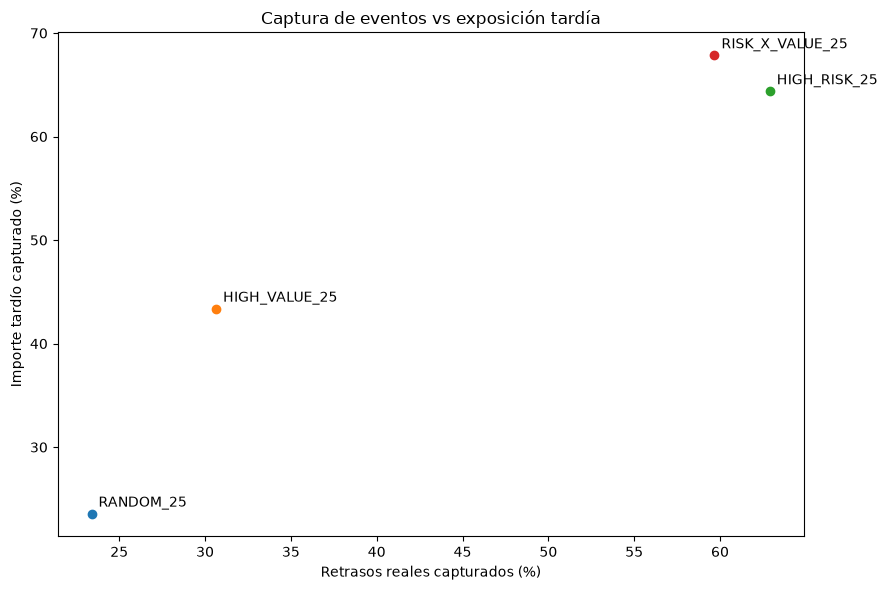

In [115]:
fig, ax = plt.subplots(
    figsize=(9, 6)
)

for _, row in (
    final_strategy_summary
    .iterrows()
):

    ax.scatter(
        row[
            "late_invoice_capture_pct"
        ] * 100,

        row[
            "late_amount_capture_pct"
        ] * 100,
    )

    ax.annotate(
        row[
            "strategy"
        ],

        (
            row[
                "late_invoice_capture_pct"
            ] * 100,

            row[
                "late_amount_capture_pct"
            ] * 100,
        ),

        xytext=(5, 5),
        textcoords="offset points",
    )

ax.set_title(
    "Captura de eventos vs exposición tardía"
)

ax.set_xlabel(
    "Retrasos reales capturados (%)"
)

ax.set_ylabel(
    "Importe tardío capturado (%)"
)

plt.tight_layout()
plt.show()

## 11. Persistencia de los resultados de integración

Para garantizar reproducibilidad y facilitar análisis posteriores se almacenarán los principales artefactos derivados.

Se conservarán:

- scores temporalmente out-of-sample;
- universo principal de integración;
- resumen final de estrategias;
- resultados del benchmark Monte Carlo.

No se sobrescribirán los datasets originales utilizados durante el proyecto.

### Ficheros de salida

In [116]:
OOS_SCORES_FILE = (
    GOLD_DIR
    / "gold_invoice_risk_oos_scores.parquet"
)

RISK_TREASURY_UNIVERSE_FILE = (
    GOLD_DIR
    / "gold_risk_treasury_validation_oos.parquet"
)

STRATEGY_RESULTS_FILE = (
    PROCESSED_DIR
    / "risk_treasury_strategy_results.parquet"
)

MONTE_CARLO_FILE = (
    PROCESSED_DIR
    / "risk_treasury_monte_carlo.parquet"
)

INTEGRATION_METADATA_FILE = (
    METADATA_DIR
    / "risk_treasury_integration_metadata.json"
)

### Guardar parquet

In [117]:
oos_risk_scores.to_parquet(
    OOS_SCORES_FILE,
    index=False,
)

primary_risk_treasury_universe.to_parquet(
    RISK_TREASURY_UNIVERSE_FILE,
    index=False,
)

final_strategy_summary.to_parquet(
    STRATEGY_RESULTS_FILE,
    index=False,
)

oos_monte_carlo.to_parquet(
    MONTE_CARLO_FILE,
    index=False,
)

print(
    "✓ Resultados Parquet guardados."
)

✓ Resultados Parquet guardados.


### Construir metadata final

In [118]:
risk_treasury_metadata = {
    "model": (
        "LogisticRegression_Model_C"
    ),

    "model_feature_count": (
        len(
            MODEL_C_FEATURES
        )
    ),

    "primary_scoring_period": (
        "VALIDATION_OOS"
    ),

    "primary_invoice_count": (
        int(
            len(
                primary_risk_treasury_universe
            )
        )
    ),

    "prioritization_share": (
        float(
            PRIORITIZATION_SHARE
        )
    ),

    "prioritization_count": (
        int(
            PRIORITIZATION_COUNT
        )
    ),

    "stress_delay_days": (
        int(
            SELECTIVE_STRESS_DAYS
        )
    ),

    "monte_carlo_repeats": (
        int(
            OOS_MONTE_CARLO_REPEATS
        )
    ),

    "validation_roc_auc": (
        float(
            oos_performance.loc[
                oos_performance[
                    "period"
                ].eq(
                    "VALIDATION_OOS"
                ),
                "roc_auc"
            ].iloc[0]
        )
    ),

    "validation_pr_auc": (
        float(
            oos_performance.loc[
                oos_performance[
                    "period"
                ].eq(
                    "VALIDATION_OOS"
                ),
                "pr_auc"
            ].iloc[0]
        )
    ),

    "test_roc_auc": (
        float(
            oos_performance.loc[
                oos_performance[
                    "period"
                ].eq(
                    "TEST_OOS"
                ),
                "roc_auc"
            ].iloc[0]
        )
    ),

    "test_pr_auc": (
        float(
            oos_performance.loc[
                oos_performance[
                    "period"
                ].eq(
                    "TEST_OOS"
                ),
                "pr_auc"
            ].iloc[0]
        )
    ),
}

### Guardar metadata

In [119]:
with open(
    INTEGRATION_METADATA_FILE,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        risk_treasury_metadata,
        file,
        indent=4,
        ensure_ascii=False,
    )

print(
    "✓ Metadata de integración guardada."
)

✓ Metadata de integración guardada.


### Verificar persistencia

In [120]:
reloaded_oos_scores = pd.read_parquet(
    OOS_SCORES_FILE
)

reloaded_risk_treasury = pd.read_parquet(
    RISK_TREASURY_UNIVERSE_FILE
)

reloaded_strategy_results = (
    pd.read_parquet(
        STRATEGY_RESULTS_FILE
    )
)

reloaded_monte_carlo = (
    pd.read_parquet(
        MONTE_CARLO_FILE
    )
)

assert (
    reloaded_oos_scores.shape
    ==
    oos_risk_scores.shape
)

assert (
    reloaded_risk_treasury.shape
    ==
    primary_risk_treasury_universe.shape
)

assert (
    reloaded_strategy_results.shape
    ==
    final_strategy_summary.shape
)

assert (
    reloaded_monte_carlo.shape
    ==
    oos_monte_carlo.shape
)

print(
    "✓ Persistencia final verificada."
)

✓ Persistencia final verificada.


In [121]:
with open(
    INTEGRATION_METADATA_FILE,
    "r",
    encoding="utf-8",
) as file:

    reloaded_integration_metadata = (
        json.load(
            file
        )
    )

assert (
    reloaded_integration_metadata[
        "model"
    ]
    ==
    "LogisticRegression_Model_C"
)

assert (
    reloaded_integration_metadata[
        "primary_invoice_count"
    ]
    ==
    len(
        primary_risk_treasury_universe
    )
)

assert (
    reloaded_integration_metadata[
        "prioritization_count"
    ]
    ==
    PRIORITIZATION_COUNT
)

assert (
    reloaded_integration_metadata[
        "monte_carlo_repeats"
    ]
    ==
    OOS_MONTE_CARLO_REPEATS
)

print(
    "✓ Metadata final verificada."
)

✓ Metadata final verificada.


## 12. Limitaciones de la integración riesgo–tesorería

La integración desarrollada permite demostrar cómo una señal predictiva puede incorporarse a un sistema de priorización financiera.

Sin embargo, los resultados deben interpretarse dentro de las limitaciones del proyecto.

### Dataset reducido

La fuente original contiene aproximadamente:

- 2.466 facturas;
- 100 clientes;
- dos años de histórico.

El universo principal de integración utiliza 381 facturas correspondientes a `VALIDATION_OOS`.

Por tanto, los resultados no pueden considerarse representativos de todas las empresas o carteras de clientes.

### Ausencia de impagos definitivos

Todas las facturas del dataset terminan siendo liquidadas.

El modelo predice:

`riesgo de retraso`

y no:

`riesgo de pérdida definitiva`.

Por tanto, el impacto financiero analizado corresponde principalmente al desplazamiento temporal de liquidez.

### Modelo binario

El modelo predice si una factura se pagará después de su vencimiento.

No estima directamente:

- fecha exacta de cobro;
- número futuro de días de retraso;
- distribución completa del momento de pago.

Una previsión de tesorería completamente ex-ante requeriría un modelo específico de tiempo hasta el cobro.

### Uso de fechas reales de liquidación

Los escenarios parten de las fechas de cobro realmente observadas y aplican sobre ellas shocks adicionales.

Por tanto, representan experimentos contrafactuales de priorización y estrés.

No constituyen una previsión histórica ex-ante completa de tesorería.

### Datos sintéticos de salidas

Las entradas de caja proceden de cobros reales del dataset.

Sin embargo, proveedores, nóminas, gastos, impuestos, financiación y saldo inicial son componentes sintéticos.

La serie de tesorería debe interpretarse como una simulación y no como la reconstrucción bancaria de una empresa real.

### Horizonte temporal

El período test no presenta cobertura completa dentro del horizonte de tesorería.

Por este motivo el experimento financiero principal utiliza `VALIDATION_OOS`, donde las 381 facturas están completamente representadas.

El test se conserva como evidencia independiente de generalización predictiva.

### Calibración probabilística

Las probabilidades del modelo son útiles como score continuo de riesgo, pero no presentan calibración perfecta en todos los niveles.

Por esta razón `predicted_risk × amount` se interpreta como criterio de ranking y no como una pérdida esperada contable.

### Benchmark Monte Carlo

Los percentiles Monte Carlo son empíricos y se calculan sobre 500 selecciones aleatorias de esta cartera concreta.

No representan probabilidades teóricas universales ni garantizan el mismo comportamiento en otros períodos o empresas.

# Conclusión final de la integración riesgo–tesorería

Este notebook conecta el modelo predictivo de retraso con la simulación diaria de tesorería desarrollada en las fases anteriores del proyecto.

El objetivo no era únicamente predecir qué facturas pagarían tarde, sino estudiar si esa información puede utilizarse para mejorar la priorización financiera.

## Validez temporal del modelo

Los scores utilizados se han generado de forma temporalmente out-of-sample.

El modelo reproduce el rendimiento obtenido durante la fase original:

### Validation

- ROC-AUC ≈ `0,904`;
- PR-AUC ≈ `0,802`.

### Test

- ROC-AUC ≈ `0,859`;
- PR-AUC ≈ `0,693`.

Esto confirma que existe una señal predictiva que se mantiene sobre períodos futuros, aunque con cierta degradación temporal.

## Universo financiero principal

La integración utiliza 381 facturas de `VALIDATION_OOS`.

Este período presenta:

- cobertura completa dentro de la simulación de tesorería;
- ausencia de truncamiento por el final del horizonte;
- scores totalmente fuera de muestra.

Las 381 facturas contienen 124 retrasos reales.

## Valor de la señal predictiva

Al seleccionar aproximadamente el 25 % de la cartera, `HIGH_RISK_25` identifica:

- 78 de los 124 retrasos reales;
- aproximadamente el 62,9 % de todos los retrasos;
- una tasa de retraso del 81,3 % dentro del grupo seleccionado.

La prevalencia general de la cartera es únicamente del 32,5 %.

Por tanto, el ranking predictivo concentra los eventos adversos con una intensidad considerablemente superior a la selección aleatoria.

## Riesgo y exposición monetaria

La estrategia `RISK_X_VALUE_25` combina:

`probabilidad estimada de retraso × importe de factura`

Esta estrategia captura:

- 74 retrasos reales;
- aproximadamente el 59,7 % de los eventos tardíos;
- aproximadamente el 67,9 % del importe total asociado a facturas tardías.

Respecto a `HIGH_RISK_25`, sacrifica ligeramente capacidad para concentrar el número de eventos, pero aumenta la exposición monetaria tardía capturada.

## Impacto sobre tesorería

Cuando el mismo shock de 10 días se aplica a todo el portfolio seleccionado, la estrategia de mayor importe genera la mayor presión de liquidez.

Este resultado confirma que la exposición monetaria es una dimensión relevante de la consecuencia financiera potencial, aunque el impacto final sobre tesorería también depende del momento en que se producen los cobros y pagos.

Sin embargo, cuando el shock se limita únicamente a las facturas seleccionadas que realmente terminaron pagando tarde, los resultados cambian.

El máximo deterioro aproximado es:

- `RANDOM_25`: 350,10;
- `HIGH_VALUE_25`: 588,17;
- `HIGH_RISK_25`: 728,83;
- `RISK_X_VALUE_25`: 909,41.

Por tanto, las estrategias que incorporan información predictiva concentran una mayor parte de la presión financiera asociada a eventos adversos realmente observados.

## Robustez frente al azar

El benchmark Monte Carlo utiliza 500 selecciones aleatorias independientes de 96 facturas.

`HIGH_RISK_25` supera todas las muestras aleatorias observadas en:

- número de retrasos capturados;
- importe tardío capturado.

Su deterioro condicionado se sitúa aproximadamente en el percentil empírico 99,8 %.

`RISK_X_VALUE_25` supera todas las muestras aleatorias observadas en:

- número de retrasos capturados;
- importe tardío capturado;
- deterioro máximo condicionado.

Su deterioro condicionado de aproximadamente 909,41 unidades monetarias supera incluso el máximo observado en las 500 selecciones aleatorias.

Estos resultados no representan probabilidades teóricas de superioridad.

Constituyen evidencia interna de que la señal predictiva concentra información relevante dentro de esta cartera y este período.

## Implicación operativa

Los resultados muestran que no existe una única estrategia óptima para todos los objetivos.

### Gestión de cobros

Si el objetivo principal es identificar el mayor número posible de facturas con elevada probabilidad de retraso:

`HIGH_RISK_25`

proporciona la señal más directa.

### Gestión de tesorería

Si el objetivo consiste en combinar probabilidad de retraso y exposición monetaria:

`RISK_X_VALUE_25`

permite priorizar operaciones donde coinciden ambas dimensiones.

Por tanto, el score predictivo puede utilizarse como una capa adicional de información dentro de un sistema de gestión financiera.

## Conclusión

Los resultados del proyecto muestran que, dentro del dataset y del entorno de simulación analizados, el comportamiento histórico de pago contiene información útil para construir un modelo interpretable de riesgo de retraso y utilizar dicha señal como apoyo a la priorización de tesorería.

La principal aportación del sistema no es predecir con certeza cuándo pagará cada cliente.

Su valor reside en transformar información histórica en un mecanismo estructurado para:

- ordenar facturas por riesgo;
- identificar exposiciones relevantes;
- priorizar seguimiento de cobros;
- construir escenarios de liquidez;
- anticipar períodos donde la disponibilidad de caja puede deteriorarse.

El sistema desarrollado debe interpretarse como un prototipo analítico y de simulación.

Una implantación empresarial real requeriría:

- un histórico más amplio;
- datos reales de cuentas a pagar y saldos bancarios;
- actualización periódica del modelo;
- monitorización de drift;
- validación recurrente de probabilidades y thresholds;
- modelado directo del tiempo hasta el cobro.

Dentro del alcance definido, la integración entre riesgo predictivo y tesorería queda demostrada de forma reproducible, temporalmente consistente y sin utilizar información futura para construir los rankings de riesgo.